In [18]:
# Імпорт бібліотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Завантаження датасету
CSV_PATH = "AirlinePassengerSatisfaction.csv"
df = pd.read_csv(CSV_PATH)

print("Розмір датасету:", df.shape)
df.head()

Розмір датасету: (103904, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [19]:
# Типи даних та кількість непустих значень по кожній колонці
df.info()
print("--- Пропущені значення ---")
missing = df.isna().sum()
missing = missing[missing > 0]
for col, cnt in missing.items():
    print(f"  {col}: {cnt} ({cnt / len(df) * 100:.2f}%)")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

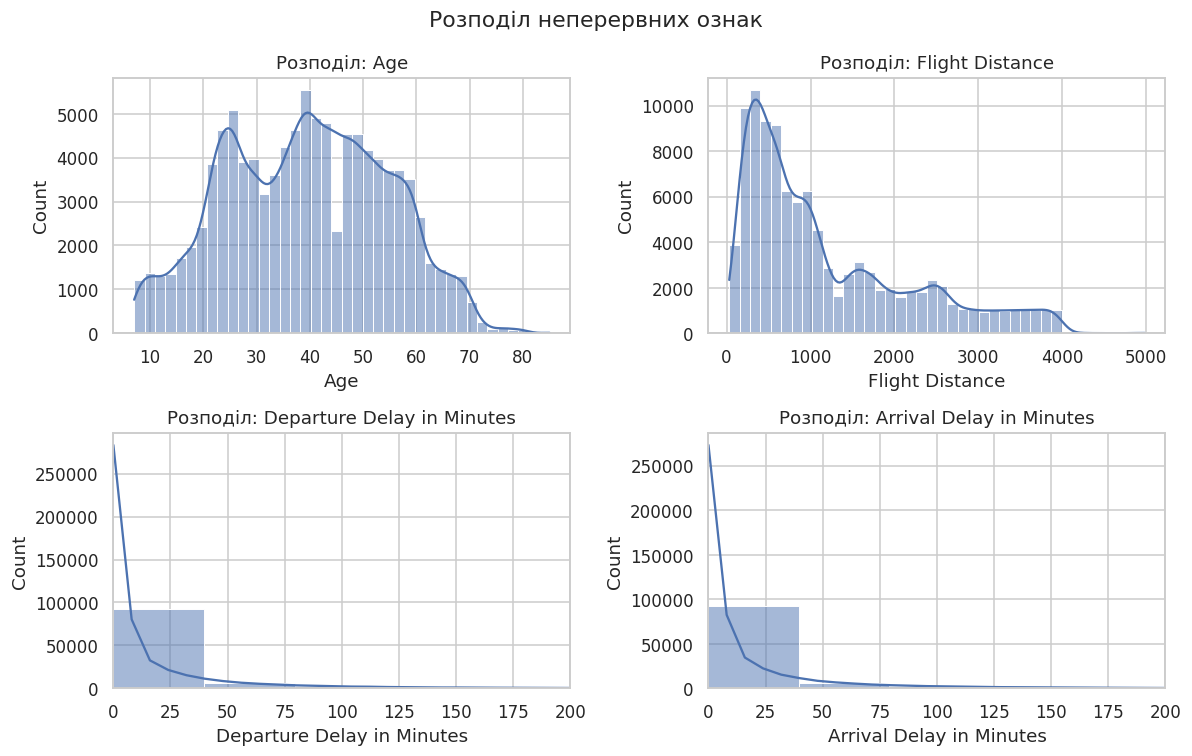

In [20]:
# Розподіл неперервних числових ознак (вік, дистанція, затримки)
num_features = ["Age", "Flight Distance",
                 "Departure Delay in Minutes", "Arrival Delay in Minutes"]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), num_features):
    sns.histplot(df[col].dropna(), bins=40, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"Розподіл: {col}")
    if "Delay" in col:
        ax.set_xlim(0, 200)  # обрізаємо довгий хвіст для наочності
fig.suptitle("Розподіл неперервних ознак")
fig.tight_layout()
plt.show()

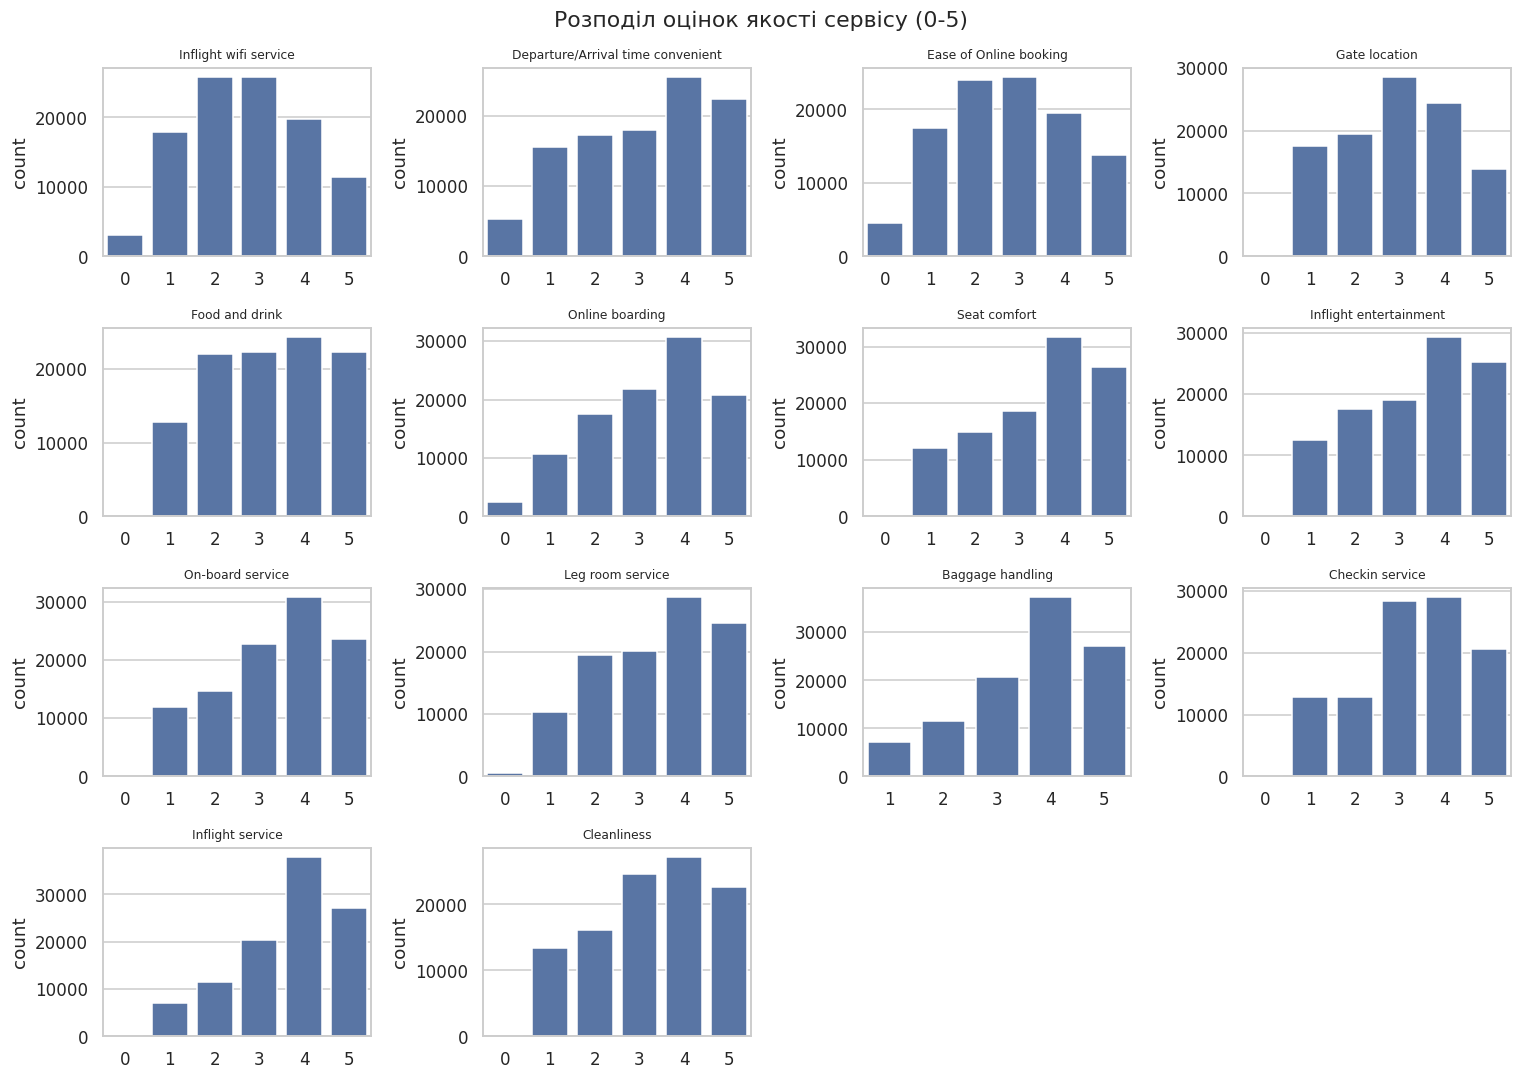

In [21]:
# Розподіл 14 порядкових ознак якості сервісу (шкала 0-5)
service_features = [
    "Inflight wifi service", "Departure/Arrival time convenient",
    "Ease of Online booking", "Gate location", "Food and drink",
    "Online boarding", "Seat comfort", "Inflight entertainment",
    "On-board service", "Leg room service", "Baggage handling",
    "Checkin service", "Inflight service", "Cleanliness",
]

fig, axes = plt.subplots(4, 4, figsize=(14, 10))
for ax, col in zip(axes.ravel(), service_features):
    sns.countplot(x=df[col], ax=ax, color="#4C72B0")
    ax.set_title(col, fontsize=8)
    ax.set_xlabel("")
for ax in axes.ravel()[len(service_features):]:
    ax.axis("off")
fig.suptitle("Розподіл оцінок якості сервісу (0-5)")
fig.tight_layout()
plt.show()

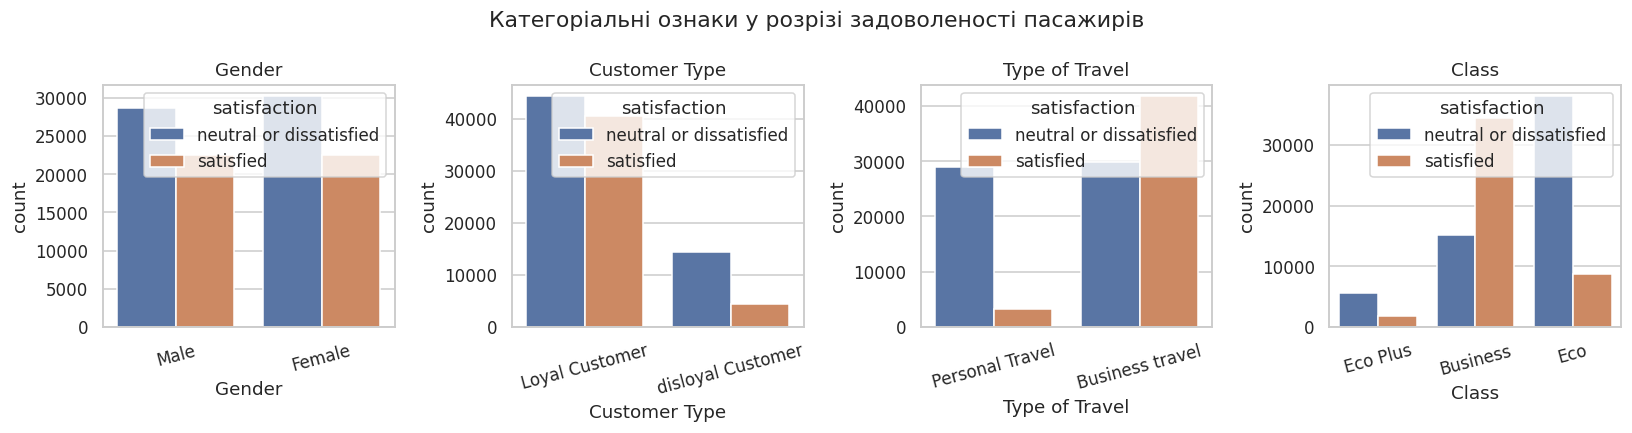

In [22]:
# Як категоріальні ознаки пов'язані з цільовою змінною satisfaction
cat_features = ["Gender", "Customer Type", "Type of Travel", "Class"]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, col in zip(axes, cat_features):
    sns.countplot(data=df, x=col, hue="satisfaction", ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=15)
fig.suptitle("Категоріальні ознаки у розрізі задоволеності пасажирів")
fig.tight_layout()
plt.show()

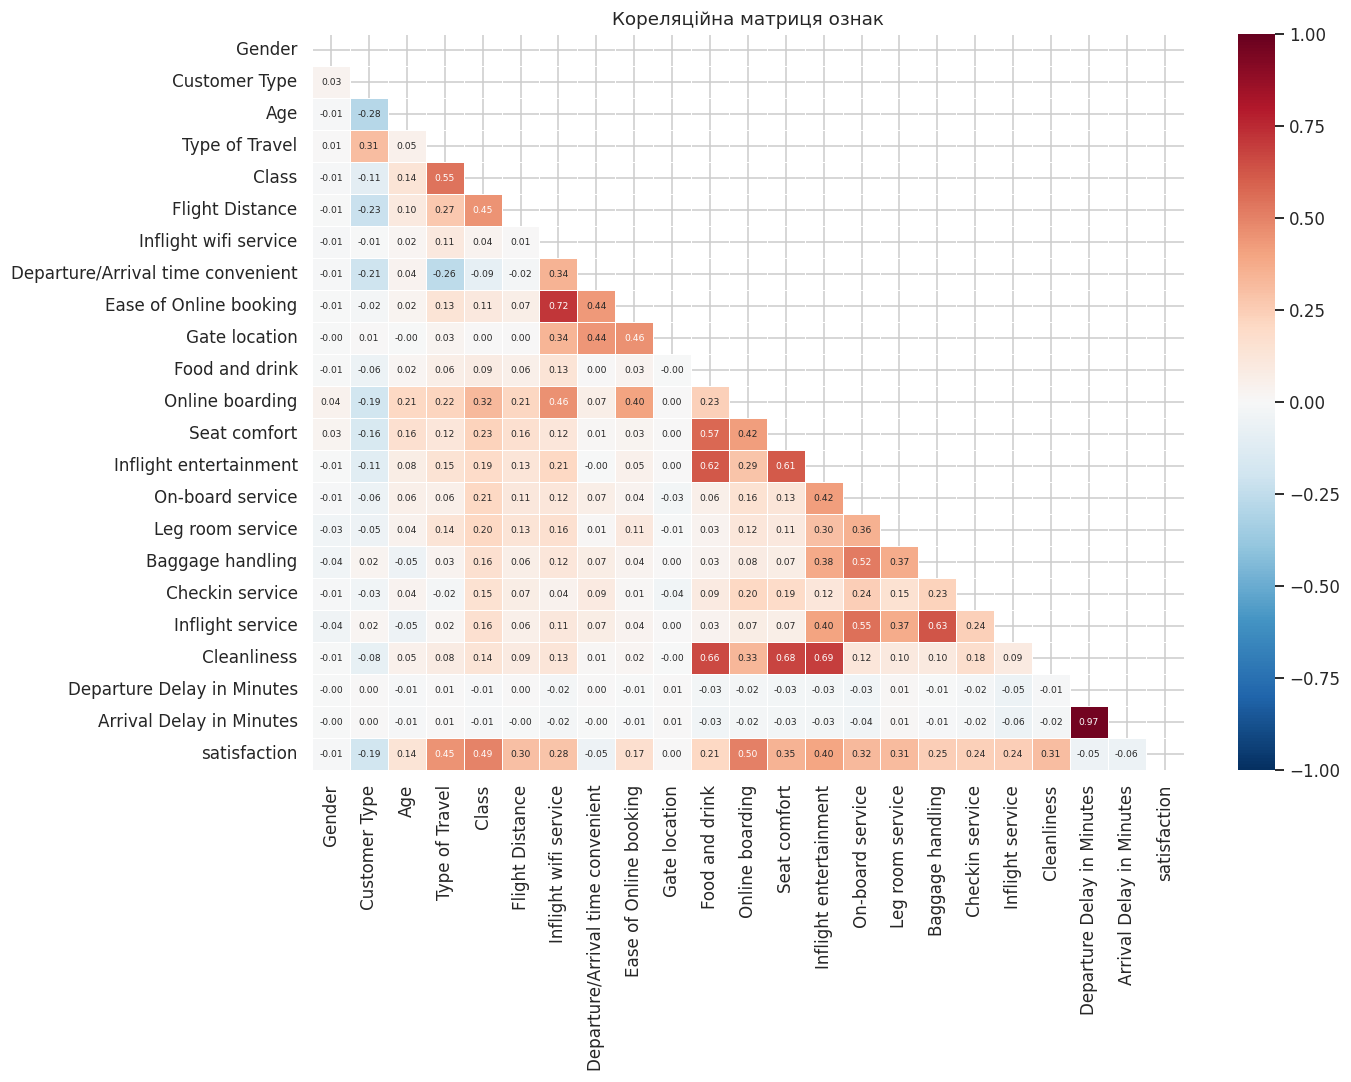

In [23]:
# Готуємо копію даних із числовим кодуванням для кореляційної матриці
df_corr = df.drop(columns=["Unnamed: 0", "id"]).copy()
df_corr["satisfaction"] = (df_corr["satisfaction"] == "satisfied").astype(int)
for col in ["Gender", "Customer Type", "Type of Travel"]:
    df_corr[col] = pd.factorize(df_corr[col])[0]
df_corr["Class"] = df_corr["Class"].map({"Eco": 0, "Eco Plus": 1, "Business": 2})

corr = df_corr.corr(numeric_only=True)

# Теплова карта кореляцій
fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 6}, linewidths=0.4, ax=ax)
ax.set_title("Кореляційна матриця ознак")
fig.tight_layout()
plt.show()

--- Кореляція ознак із satisfaction ---
Online boarding                      0.504
Class                                0.494
Type of Travel                       0.449
Inflight entertainment               0.398
Seat comfort                         0.349
On-board service                     0.322
Leg room service                     0.313
Cleanliness                          0.305
Flight Distance                      0.299
Inflight wifi service                0.284
Baggage handling                     0.248
Inflight service                     0.245
Checkin service                      0.236
Food and drink                       0.210
Ease of Online booking               0.172
Age                                  0.137
Gate location                        0.001
Gender                              -0.012
Departure Delay in Minutes          -0.050
Departure/Arrival time convenient   -0.052
Arrival Delay in Minutes            -0.058
Customer Type                       -0.188


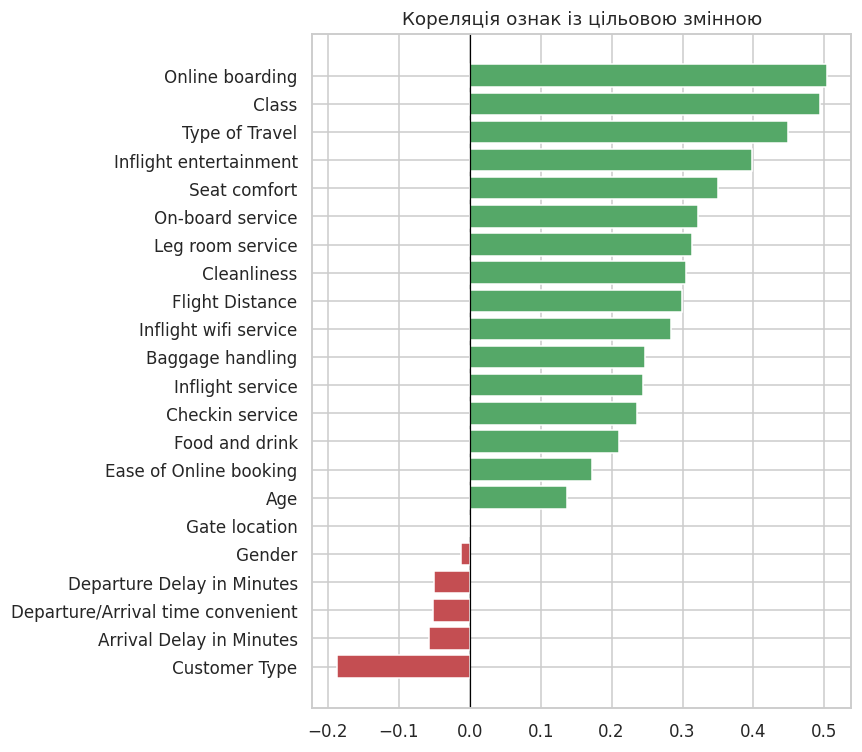


--- Пари сильно корельованих ознак (|r| > 0.5) ---
  Departure Delay in Minutes  <->  Arrival Delay in Minutes:  r = 0.965
  Inflight wifi service  <->  Ease of Online booking:  r = 0.716
  Inflight entertainment  <->  Cleanliness:  r = 0.692
  Seat comfort  <->  Cleanliness:  r = 0.679
  Food and drink  <->  Cleanliness:  r = 0.658
  Baggage handling  <->  Inflight service:  r = 0.629
  Food and drink  <->  Inflight entertainment:  r = 0.623
  Seat comfort  <->  Inflight entertainment:  r = 0.611
  Food and drink  <->  Seat comfort:  r = 0.575
  On-board service  <->  Inflight service:  r = 0.551
  Type of Travel  <->  Class:  r = 0.545
  On-board service  <->  Baggage handling:  r = 0.519
  Online boarding  <->  satisfaction:  r = 0.504


In [24]:
# Кореляція кожної ознаки з цільовою змінною satisfaction
target_corr = corr["satisfaction"].drop("satisfaction").sort_values(ascending=False)
print("--- Кореляція ознак із satisfaction ---")
print(target_corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#55A868" if v > 0 else "#C44E52" for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.invert_yaxis()
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Кореляція ознак із цільовою змінною")
fig.tight_layout()
plt.show()

# Пари ознак із сильною взаємною кореляцією (|r| > 0.5) - перевірка мультиколінеарності
print("\n--- Пари сильно корельованих ознак (|r| > 0.5) ---")
pairs = corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1)).stack()
strong = pairs[pairs.abs() > 0.5].sort_values(ascending=False)
for (a, b), v in strong.items():
    print(f"  {a}  <->  {b}:  r = {v:.3f}")

--- Розподіл цільового класу ---
  neutral or dissatisfied   :  58879  (56.67%)
  satisfied                 :  45025  (43.33%)

Коефіцієнт дисбалансу (majority/minority): 1.308 : 1


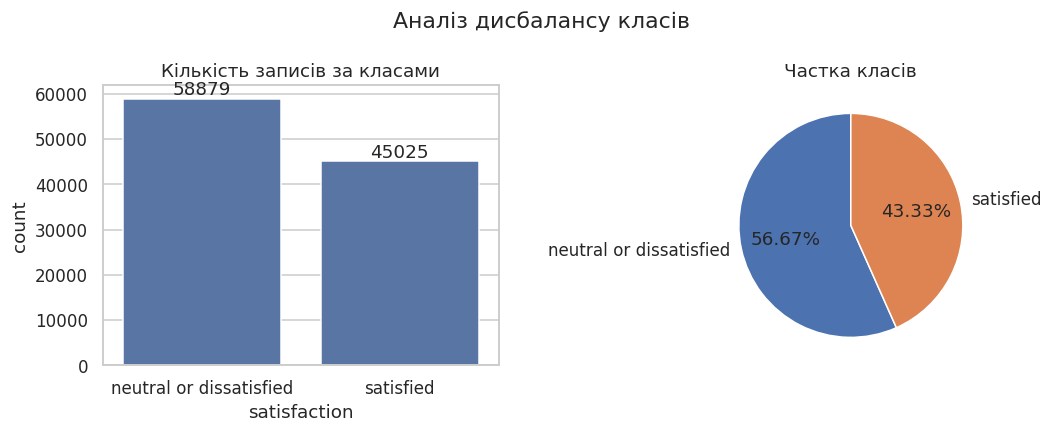

In [25]:
# Аналіз балансу цільового класу satisfaction
counts = df["satisfaction"].value_counts()
shares = df["satisfaction"].value_counts(normalize=True)

print("--- Розподіл цільового класу ---")
for cls in counts.index:
    print(f"  {cls:<26}: {counts[cls]:>6}  ({shares[cls] * 100:.2f}%)")

imbalance_ratio = counts.max() / counts.min()
print(f"\nКоефіцієнт дисбалансу (majority/minority): {imbalance_ratio:.3f} : 1")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(data=df, x="satisfaction", ax=axes[0])
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%d")
axes[0].set_title("Кількість записів за класами")

axes[1].pie(counts.values, labels=counts.index, autopct="%1.2f%%", startangle=90)
axes[1].set_title("Частка класів")

fig.suptitle("Аналіз дисбалансу класів")
fig.tight_layout()
plt.show()

In [26]:
# Створюємо робочу копію датасету, щоб не змінювати оригінальний df
data = df.copy()
# Виводимо початковий розмір таблиці (рядки, колонки)
print("Початковий розмір:", data.shape)

# Видаляємо службові колонки: 'Unnamed: 0' - старий індекс, 'id' - номер пасажира;
# вони не несуть корисної інформації для навчання моделі
data = data.drop(columns=["Unnamed: 0", "id"])
# Перевіряємо розмір після видалення (має стати на 2 колонки менше)
print("Після видалення 'Unnamed: 0' та 'id':", data.shape)

# Рахуємо кількість пропущених значень у колонці затримки прибуття
n_missing = data["Arrival Delay in Minutes"].isna().sum()
# Заповнюємо пропуски значенням затримки вильоту того ж рейсу:
# за кореляційним аналізом ці ознаки майже тотожні (r = 0.965)
data["Arrival Delay in Minutes"] = data["Arrival Delay in Minutes"].fillna(
    data["Departure Delay in Minutes"])
# Виводимо, скільки пропусків заповнено і скільки залишилось у всьому датасеті
print(f"Заповнено пропусків: {n_missing}, залишилось: {data.isna().sum().sum()}")

# Перевіряємо наявність повністю однакових рядків (дублікатів)
print("Кількість дублікатів:", data.duplicated().sum())

Початковий розмір: (103904, 25)
Після видалення 'Unnamed: 0' та 'id': (103904, 23)
Заповнено пропусків: 310, залишилось: 0
Кількість дублікатів: 0


In [27]:
# Словник відповідностей для бінарних категоріальних ознак (дві категорії -> 0/1)
binary_map = {
    # Стать пасажира: чоловік = 0, жінка = 1
    "Gender":         {"Male": 0, "Female": 1},
    # Тип клієнта: нелояльний = 0, лояльний = 1
    "Customer Type":  {"disloyal Customer": 0, "Loyal Customer": 1},
    # Мета подорожі: особиста = 0, ділова = 1
    "Type of Travel": {"Personal Travel": 0, "Business travel": 1},
}
# Проходимо по кожній бінарній ознаці та її словнику відповідностей
for col, mapping in binary_map.items():
    # Замінюємо текстові значення на числові згідно зі словником
    data[col] = data[col].map(mapping)

# Class має 3 категорії (Eco, Eco Plus, Business), тому кодуємо через one-hot:
# створюються 3 окремі колонки 0/1. Порядкове кодування (0, 1, 2) задало б
# нейромережі штучну "відстань" між класами обслуговування
data = pd.get_dummies(data, columns=["Class"], prefix="Class", dtype=int)

# Кодуємо цільову змінну: satisfied = 1, neutral or dissatisfied = 0
data["satisfaction"] = (data["satisfaction"] == "satisfied").astype(int)

# Виводимо новий розмір таблиці (з'явились колонки one-hot)
print("Розмір після кодування:", data.shape)
# Перевіряємо, що всі колонки тепер числові (жодної типу object)
print("Типи даних:", data.dtypes.value_counts().to_dict())
# Показуємо перші 5 рядків закодованої таблиці
data.head()

Розмір після кодування: (103904, 25)
Типи даних: {dtype('int64'): 24, dtype('float64'): 1}


,Gender,Customer Type,Age,Type of Travel,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction,Class_Business,Class_Eco,Class_Eco Plus
0,0,1,13,0,460,3,4,3,1,5,...,4,4,5,5,25,18.0,0,0,0,1
1,0,0,25,1,235,3,2,3,3,1,...,3,1,4,1,1,6.0,0,1,0,0
2,1,1,26,1,1142,2,2,2,2,5,...,4,4,4,5,0,0.0,1,1,0,0
3,1,1,25,1,562,2,5,5,5,2,...,3,1,4,2,11,9.0,0,1,0,0
4,0,1,61,1,214,3,3,3,3,4,...,4,3,3,3,0,0.0,1,1,0,0


                            Асиметрія до  Асиметрія після log1p
Flight Distance                     1.11                  -0.20
Departure Delay in Minutes          6.73                   0.92
Arrival Delay in Minutes            6.56                   0.87


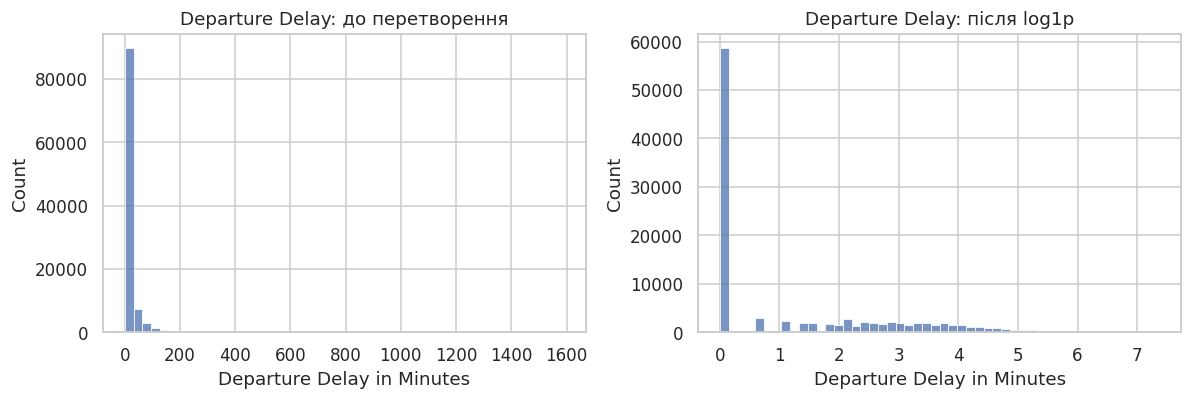

In [28]:
# Список ознак із сильною правосторонньою асиметрією (виявлено в EDA)
skewed = ["Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]

# Обчислюємо коефіцієнт асиметрії (skewness) до перетворення
skew_before = data[skewed].skew()
# Застосовуємо log(1 + x): стискає довгий правий хвіст розподілу
# і коректно працює з нулями (log(1 + 0) = 0)
data[skewed] = np.log1p(data[skewed])
# Обчислюємо коефіцієнт асиметрії після перетворення
skew_after = data[skewed].skew()

# Виводимо таблицю порівняння асиметрії до і після, округлену до 2 знаків
print(pd.DataFrame({"Асиметрія до": skew_before.round(2),
                    "Асиметрія після log1p": skew_after.round(2)}))

# Створюємо фігуру з двома графіками поруч
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
# Лівий графік: розподіл затримки вильоту в оригінальних даних (df не змінювався)
sns.histplot(df["Departure Delay in Minutes"], bins=50, ax=axes[0])
# Підпис лівого графіка
axes[0].set_title("Departure Delay: до перетворення")
# Правий графік: розподіл тієї ж ознаки після логарифмування
sns.histplot(data["Departure Delay in Minutes"], bins=50, ax=axes[1])
# Підпис правого графіка
axes[1].set_title("Departure Delay: після log1p")
# Автоматично вирівнюємо відступи між графіками
fig.tight_layout()
# Відображаємо графіки
plt.show()

In [29]:
# Матриця ознак X: усі колонки, крім цільової змінної
X = data.drop(columns=["satisfaction"])
# Вектор міток y: значення цільової змінної у вигляді масиву numpy
y = data["satisfaction"].values
# Зберігаємо список назв ознак (знадобиться для аналізу та графіків)
FEATURE_NAMES = list(X.columns)

# Виводимо розмірності X та y
print("X:", X.shape, " y:", y.shape)
# Виводимо перелік усіх ознак, що подаватимуться на вхід моделі
print("Ознаки:", FEATURE_NAMES)

X: (103904, 24)  y: (103904,)
Ознаки: ['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Class_Business', 'Class_Eco', 'Class_Eco Plus']


PC1 пояснює 17.99%, PC2 - 10.02% дисперсії
Для 90% дисперсії потрібно 15 компонент із 24
Для 95% дисперсії потрібно 19 компонент із 24


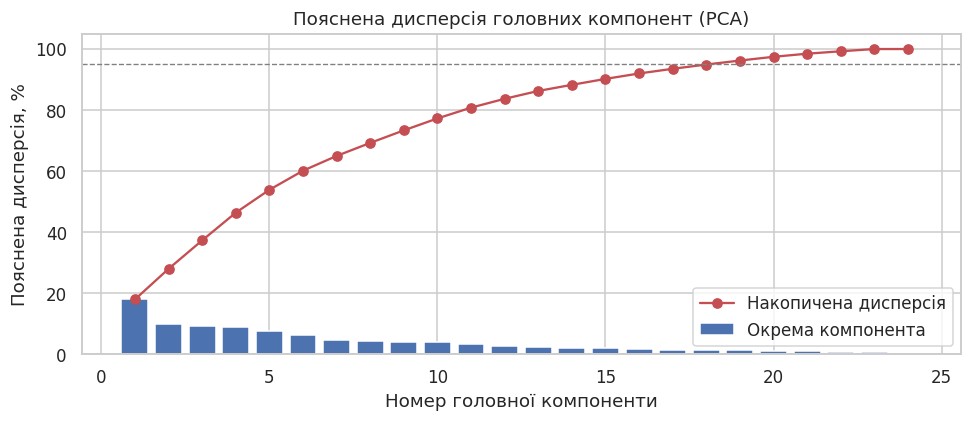

In [30]:
# Імпортуємо стандартизацію ознак і метод головних компонент
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# PCA чутливий до масштабу ознак, тому спершу приводимо їх до mean = 0, std = 1.
# Тут PCA використовується лише для аналізу розмірності, тому scaler навчаємо на всіх
# даних; для моделей масштабування буде виконано окремо, лише на train (п. 5)
X_std = StandardScaler().fit_transform(X)

# Навчаємо PCA з усіма компонентами (їх стільки ж, скільки ознак)
pca = PCA(random_state=42).fit(X_std)
# Частка дисперсії, яку пояснює кожна компонента окремо
explained = pca.explained_variance_ratio_
# Накопичена (кумулятивна) частка поясненої дисперсії
cumulative = np.cumsum(explained)

# Мінімальна кількість компонент, що пояснюють 90% дисперсії
n90 = np.argmax(cumulative >= 0.90) + 1
# Мінімальна кількість компонент, що пояснюють 95% дисперсії
n95 = np.argmax(cumulative >= 0.95) + 1
# Виводимо внесок перших двох компонент
print(f"PC1 пояснює {explained[0]*100:.2f}%, PC2 - {explained[1]*100:.2f}% дисперсії")
# Виводимо, скільки компонент потрібно для 90% і 95% дисперсії
print(f"Для 90% дисперсії потрібно {n90} компонент із {X.shape[1]}")
print(f"Для 95% дисперсії потрібно {n95} компонент із {X.shape[1]}")

# Створюємо фігуру для scree-діаграми
fig, ax = plt.subplots(figsize=(9, 4))
# Стовпчики: дисперсія, яку пояснює кожна компонента, у відсотках
ax.bar(range(1, len(explained) + 1), explained * 100, label="Окрема компонента")
# Лінія: накопичена пояснена дисперсія у відсотках
ax.plot(range(1, len(cumulative) + 1), cumulative * 100, "o-", color="#C44E52",
        label="Накопичена дисперсія")
# Горизонтальна пунктирна лінія на рівні 95%
ax.axhline(95, ls="--", color="gray", linewidth=0.9)
# Підписи осей і заголовок графіка
ax.set_xlabel("Номер головної компоненти")
ax.set_ylabel("Пояснена дисперсія, %")
ax.set_title("Пояснена дисперсія головних компонент (PCA)")
# Легенда графіка
ax.legend()
# Вирівнюємо відступи та відображаємо графік
fig.tight_layout()
plt.show()

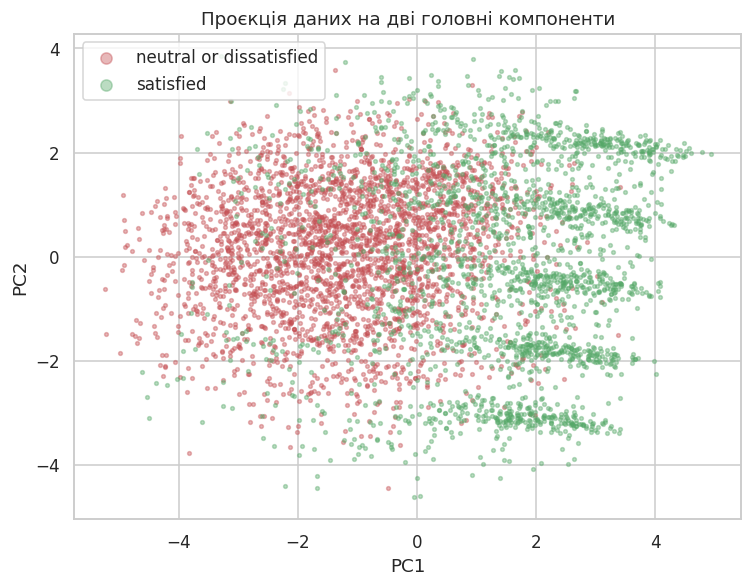

In [31]:
# Стискаємо дані до двох головних компонент для візуалізації на площині
X_2d = PCA(n_components=2, random_state=42).fit_transform(X_std)
# Випадково обираємо 5000 точок, щоб графік не був перевантажений
idx = np.random.RandomState(42).choice(len(X_2d), 5000, replace=False)

# Створюємо фігуру для діаграми розсіювання
fig, ax = plt.subplots(figsize=(7, 5.5))
# Для кожного класу задаємо колір і підпис: червоний - незадоволені, зелений - задоволені
for cls, color, label in [(0, "#C44E52", "neutral or dissatisfied"),
                          (1, "#55A868", "satisfied")]:
    # Маска: які з обраних точок належать поточному класу
    m = y[idx] == cls
    # Малюємо точки класу в координатах PC1 та PC2
    ax.scatter(X_2d[idx][m, 0], X_2d[idx][m, 1], s=6, alpha=0.4, c=color, label=label)
# Підписи осей і заголовок графіка
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Проєкція даних на дві головні компоненти")
# Легенда зі збільшеними маркерами для кращої видимості
ax.legend(markerscale=3)
# Вирівнюємо відступи та відображаємо графік
fig.tight_layout()
plt.show()

In [32]:
# Імпортуємо функцію для розбиття даних на вибірки
from sklearn.model_selection import train_test_split

# Фіксоване зерно генератора, щоб поділ був однаковим при кожному запуску
SEED = 42

# Крок 1: відокремлюємо тестову вибірку (15% усіх даних);
# stratify=y зберігає однакову пропорцію класів в обох частинах
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y)

# Крок 2: з решти 85% відокремлюємо валідаційну вибірку;
# частка 0.15 / 0.85 від залишку дає рівно 15% від усіх даних
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15 / 0.85, random_state=SEED, stratify=y_temp)

# Загальна кількість записів для обчислення відсотків
total = len(X)
# Для кожної вибірки виводимо кількість записів, її частку та частку класу satisfied
for name, Xs, ys in [("Train", X_train, y_train),
                     ("Validation", X_val, y_val),
                     ("Test", X_test, y_test)]:
    print(f"{name:<11}: {len(Xs):>6} записів ({len(Xs) / total * 100:.2f}%), "
          f"частка satisfied: {ys.mean() * 100:.2f}%")

Train      :  72732 записів (70.00%), частка satisfied: 43.33%
Validation :  15586 записів (15.00%), частка satisfied: 43.33%
Test       :  15586 записів (15.00%), частка satisfied: 43.33%


            neutral or dissatisfied  satisfied
Вибірка                                       
Train                         41215      31517
Validation                     8832       6754
Test                           8832       6754


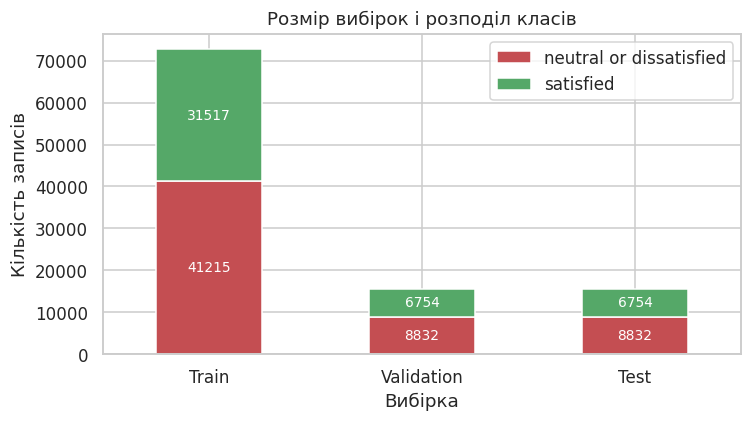

In [33]:
# Таблиця: кількість записів кожного класу в кожній вибірці
split_df = pd.DataFrame({
    # Назви вибірок
    "Вибірка": ["Train", "Validation", "Test"],
    # Кількість незадоволених пасажирів (клас 0) у кожній вибірці
    "neutral or dissatisfied": [(y_train == 0).sum(), (y_val == 0).sum(), (y_test == 0).sum()],
    # Кількість задоволених пасажирів (клас 1) у кожній вибірці
    "satisfied": [(y_train == 1).sum(), (y_val == 1).sum(), (y_test == 1).sum()],
}).set_index("Вибірка")
# Виводимо таблицю
print(split_df)

# Складена стовпчикова діаграма: висота стовпця - розмір вибірки, кольори - класи
ax = split_df.plot(kind="bar", stacked=True, figsize=(7, 4),
                   color=["#C44E52", "#55A868"], rot=0)
# Підписуємо кількість записів усередині кожного сегмента стовпця
for c in ax.containers:
    ax.bar_label(c, label_type="center", fmt="%d", color="white", fontsize=9)
# Підпис осі Y і заголовок графіка
ax.set_ylabel("Кількість записів")
ax.set_title("Розмір вибірок і розподіл класів")
# Вирівнюємо відступи та відображаємо графік
plt.tight_layout()
plt.show()

In [34]:
# Імпортуємо стандартизацію ознак
from sklearn.preprocessing import StandardScaler

# Створюємо об'єкт стандартизації: кожна ознака приводиться до mean = 0 і std = 1
scaler = StandardScaler()
# Навчаємо scaler ТІЛЬКИ на train (обчислюємо середнє і std) та одразу трансформуємо train
X_train_sc = scaler.fit_transform(X_train)
# Val і test трансформуємо з параметрами, обчисленими на train, щоб уникнути витоку даних
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

# Перевірка: у train середнє = 0 і std = 1, у val і test - дуже близько до цього
print("Train: mean =", X_train_sc.mean().round(3), " std =", X_train_sc.std().round(3))
print("Val  : mean =", X_val_sc.mean().round(3), " std =", X_val_sc.std().round(3))
print("Test : mean =", X_test_sc.mean().round(3), " std =", X_test_sc.std().round(3))

Train: mean = 0.0  std = 1.0
Val  : mean = -0.003  std = 1.0
Test : mean = -0.002  std = 0.999


До SMOTE   : [41215 31517] (усього 72732)
Після SMOTE: [41215 41215] (усього 82430)
Додано синтетичних записів: 9698


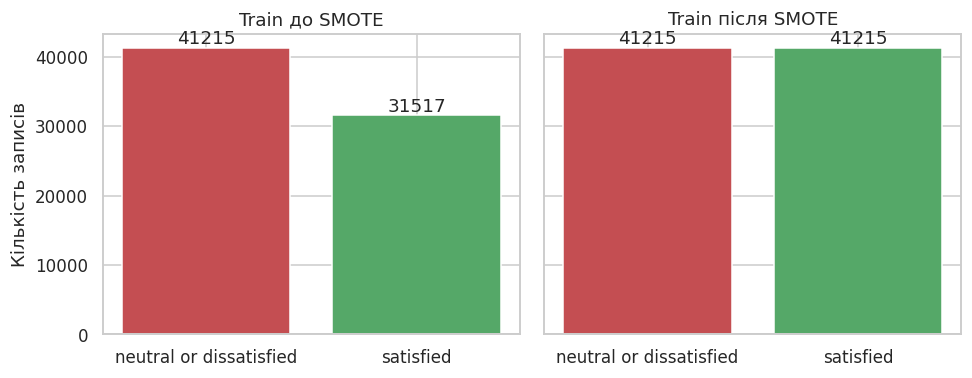

In [35]:
# Імпортуємо SMOTE з бібліотеки imbalanced-learn
# (якщо бібліотеки немає, виконай в окремій клітинці: !pip install imbalanced-learn)
from imblearn.over_sampling import SMOTE

# Створюємо об'єкт SMOTE: нові приклади класу-меншості генеруються
# на відрізках між записом і його 5 найближчими сусідами того ж класу
smote = SMOTE(random_state=SEED, k_neighbors=5)
# Балансуємо ТІЛЬКИ навчальну вибірку; val і test лишаються з реальним розподілом класів
X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)

# Кількість записів кожного класу [клас 0, клас 1] до та після балансування
print("До SMOTE   :", np.bincount(y_train), f"(усього {len(y_train)})")
print("Після SMOTE:", np.bincount(y_train_bal), f"(усього {len(y_train_bal)})")
# Скільки синтетичних записів додано
print("Додано синтетичних записів:", len(y_train_bal) - len(y_train))

# Два графіки поруч зі спільною віссю Y для порівняння
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharey=True)
# Малюємо розподіл класів до і після SMOTE
for ax, labels, title in [(axes[0], y_train, "Train до SMOTE"),
                          (axes[1], y_train_bal, "Train після SMOTE")]:
    # Рахуємо кількість записів кожного класу
    counts = np.bincount(labels)
    # Стовпчики: червоний - незадоволені, зелений - задоволені
    bars = ax.bar(["neutral or dissatisfied", "satisfied"], counts,
                  color=["#C44E52", "#55A868"])
    # Підписуємо кількість над кожним стовпчиком
    ax.bar_label(bars, fmt="%d")
    # Заголовок графіка
    ax.set_title(title)
# Підпис осі Y для лівого графіка
axes[0].set_ylabel("Кількість записів")
# Вирівнюємо відступи та відображаємо графіки
fig.tight_layout()
plt.show()

In [36]:
# Імпортуємо TensorFlow і модулі Keras: шари, моделі та регуляризатори
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

# Фіксуємо зерно для Python, NumPy і TensorFlow, щоб результати були відтворюваними
tf.keras.utils.set_random_seed(SEED)
# Виводимо версію TensorFlow
print("Версія TensorFlow:", tf.__version__)

# Кількість вхідних ознак мережі (кількість колонок навчальної вибірки)
INPUT_DIM = X_train_bal.shape[1]
print("Кількість вхідних ознак:", INPUT_DIM)


# Функція повертає шар активації за назвою, щоб легко перемикати активації в експериментах
def make_activation(name):
    # ReLU: f(z) = max(0, z)
    if name == "relu":
        return layers.ReLU()
    # LeakyReLU: для від'ємних z залишає невеликий нахил 0.1 замість нуля
    if name == "leaky_relu":
        try:
            # Синтаксис Keras 3 (актуальні версії TensorFlow)
            return layers.LeakyReLU(negative_slope=0.1)
        except TypeError:
            # Синтаксис Keras 2 (старіші версії TensorFlow)
            return layers.LeakyReLU(alpha=0.1)
    # GELU: гладка активація, яка зважує вхід за ймовірністю нормального розподілу
    if name == "gelu":
        return layers.Activation("gelu")
    # Якщо передано невідому назву, зупиняємо виконання з помилкою
    raise ValueError(f"Невідома функція активації: {name}")

Версія TensorFlow: 2.20.0
Кількість вхідних ознак: 24


In [37]:
# Базова мережа прямого поширення: 3 приховані шари без жодної регуляризації
def build_base_model(activation="relu"):
    # Створюємо послідовну модель (шари йдуть один за одним)
    model = models.Sequential(name=f"Base_{activation}")
    # Вхідний шар: приймає вектор із INPUT_DIM ознак
    model.add(layers.Input(shape=(INPUT_DIM,)))

    # 1-й прихований шар: 256 нейронів + функція активації
    model.add(layers.Dense(256, name="dense_1"))
    model.add(make_activation(activation))

    # 2-й прихований шар: 128 нейронів + функція активації
    model.add(layers.Dense(128, name="dense_2"))
    model.add(make_activation(activation))

    # 3-й прихований шар: 64 нейрони + функція активації
    model.add(layers.Dense(64, name="dense_3"))
    model.add(make_activation(activation))

    # Вихідний шар: 1 нейрон із сигмоїдою повертає ймовірність класу satisfied (0..1)
    model.add(layers.Dense(1, activation="sigmoid", name="output"))
    # Повертаємо зібрану модель
    return model


# Створюємо демонстраційний екземпляр з ReLU та виводимо структуру мережі
base_demo = build_base_model("relu")
base_demo.summary()

Model: "Base_relu"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,617 (186.00 KB)

 Trainable params: 47,617 (186.00 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Коефіцієнт L2-регуляризації: штраф за великі ваги, що додається до функції втрат
L2_LAMBDA = 1e-4
# Частка нейронів, які Dropout випадково вимикає на кожному кроці навчання
DROPOUT_RATES = [0.3, 0.3, 0.2]


# Ускладнена мережа: ті самі 3 шари, але кожен доповнений регуляризацією
def build_optimized_model(activation="relu"):
    # Створюємо послідовну модель
    model = models.Sequential(name=f"Optimized_{activation}")
    # Вхідний шар: приймає вектор із INPUT_DIM ознак
    model.add(layers.Input(shape=(INPUT_DIM,)))

    # Проходимо по трьох прихованих шарах: кількість нейронів і частка Dropout для кожного
    for i, (units, rate) in enumerate(zip([256, 128, 64], DROPOUT_RATES), start=1):
        # Повнозв'язний шар з L2-регуляризацією ваг
        model.add(layers.Dense(units,
                               kernel_regularizer=regularizers.l2(L2_LAMBDA),
                               name=f"dense_{i}"))
        # Batch Normalization: нормалізує виходи шару в межах батча, стабілізує навчання
        model.add(layers.BatchNormalization(name=f"batchnorm_{i}"))
        # Функція активації
        model.add(make_activation(activation))
        # Dropout: випадково вимикає частину нейронів, щоб мережа не запам'ятовувала дані
        model.add(layers.Dropout(rate, name=f"dropout_{i}"))

    # Вихідний шар: 1 нейрон із сигмоїдою повертає ймовірність класу satisfied
    model.add(layers.Dense(1, activation="sigmoid", name="output"))
    # Повертаємо зібрану модель
    return model


# Створюємо демонстраційний екземпляр з ReLU та виводимо структуру мережі
opt_demo = build_optimized_model("relu")
opt_demo.summary()

Model: "Optimized_relu"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_1                     │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_2                     │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_3                     │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,409 (193.00 KB)

 Trainable params: 48,513 (189.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [39]:
# Зводимо ключові характеристики обох архітектур в одну таблицю
comparison = pd.DataFrame({
    # Характеристики базової мережі
    "Базова": ["256 - 128 - 64", "ні", "ні", "ні",
               f"{base_demo.count_params():,}".replace(",", " ")],
    # Характеристики ускладненої мережі
    "Ускладнена": ["256 - 128 - 64", "так, після кожного Dense", "0.3 / 0.3 / 0.2",
                   f"так, λ = {L2_LAMBDA}",
                   f"{opt_demo.count_params():,}".replace(",", " ")],
# Назви рядків таблиці
}, index=["Приховані шари (нейрони)", "Batch Normalization", "Dropout",
          "L2-регуляризація", "Кількість параметрів"])
# Виводимо таблицю
print(comparison.to_string())

                                  Базова                Ускладнена
Приховані шари (нейрони)  256 - 128 - 64            256 - 128 - 64
Batch Normalization                   ні  так, після кожного Dense
Dropout                               ні           0.3 / 0.3 / 0.2
L2-регуляризація                      ні           так, λ = 0.0001
Кількість параметрів              47 617                    49 409


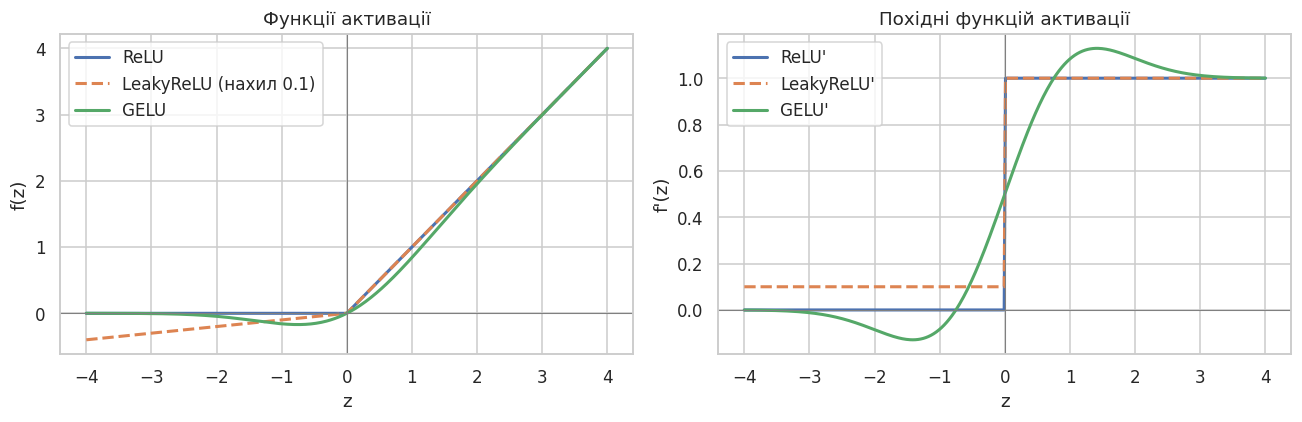

In [40]:
# Функція помилок erf потрібна для точної формули GELU
from scipy.special import erf

# 400 рівномірних точок на відрізку [-4; 4] - вхідні значення нейрона z
z = np.linspace(-4, 4, 400)

# ReLU: f(z) = max(0, z) - від'ємні значення обнуляються
relu = np.maximum(0, z)
# LeakyReLU: для від'ємних z зберігається нахил 0.1 (як у нашій мережі)
leaky = np.where(z > 0, z, 0.1 * z)
# GELU: f(z) = z * Ф(z), де Ф - функція розподілу стандартного нормального закону
gelu = 0.5 * z * (1 + erf(z / np.sqrt(2)))

# Похідна ReLU: 1 для z > 0, 0 для z <= 0 (нейрон не навчається при від'ємному вході)
d_relu = np.where(z > 0, 1.0, 0.0)
# Похідна LeakyReLU: 1 для z > 0, 0.1 для z <= 0 (градієнт ніколи не зникає повністю)
d_leaky = np.where(z > 0, 1.0, 0.1)
# Похідна GELU обчислюється чисельно (гладка крива без зламу в нулі)
d_gelu = np.gradient(gelu, z)

# Два графіки поруч: функції активації та їхні похідні
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Лівий графік: самі функції активації
axes[0].plot(z, relu, linewidth=2, label="ReLU")
axes[0].plot(z, leaky, linewidth=2, linestyle="--", label="LeakyReLU (нахил 0.1)")
axes[0].plot(z, gelu, linewidth=2, label="GELU")
# Заголовок і підписи осей
axes[0].set_title("Функції активації")
axes[0].set_xlabel("z")
axes[0].set_ylabel("f(z)")
# Осі координат для орієнтира
axes[0].axhline(0, color="gray", linewidth=0.7)
axes[0].axvline(0, color="gray", linewidth=0.7)
# Легенда
axes[0].legend()

# Правий графік: похідні, які визначають величину градієнта під час навчання
axes[1].plot(z, d_relu, linewidth=2, label="ReLU'")
axes[1].plot(z, d_leaky, linewidth=2, linestyle="--", label="LeakyReLU'")
axes[1].plot(z, d_gelu, linewidth=2, label="GELU'")
# Заголовок і підписи осей
axes[1].set_title("Похідні функцій активації")
axes[1].set_xlabel("z")
axes[1].set_ylabel("f'(z)")
# Осі координат для орієнтира
axes[1].axhline(0, color="gray", linewidth=0.7)
axes[1].axvline(0, color="gray", linewidth=0.7)
# Легенда
axes[1].legend()

# Вирівнюємо відступи та відображаємо графіки
fig.tight_layout()
plt.show()

In [41]:
# Модуль time потрібен для вимірювання часу навчання кожної моделі
import time

# Фіксовані гіперпараметри, однакові для всіх експериментів
EPOCHS = 20            # кількість епох навчання (у межах 10-20 за завданням)
BATCH_SIZE = 256       # кількість записів в одному батчі
LEARNING_RATE = 1e-3   # швидкість навчання оптимізатора Adam

# Три функції активації, які порівнюємо
ACTIVATIONS = ["relu", "leaky_relu", "gelu"]
# Назви активацій для таблиць і графіків
ACT_LABELS = {"relu": "ReLU", "leaky_relu": "LeakyReLU", "gelu": "GELU"}
# Відповідність назви архітектури і функції, що її будує (з пункту 6)
BUILDERS = {"Базова": build_base_model, "Ускладнена": build_optimized_model}


# Callback, який після кожної епохи друкує короткий рядок із метриками
class EpochLogger(tf.keras.callbacks.Callback):
    # Метод автоматично викликається Keras наприкінці кожної епохи
    def on_epoch_end(self, epoch, logs=None):
        # Друкуємо номер епохи, втрати й точність на train та validation
        print(f"  Епоха {epoch + 1:02d}/{EPOCHS}   "
              f"loss: {logs['loss']:.4f}   acc: {logs['accuracy']:.4f}   |   "
              f"val_loss: {logs['val_loss']:.4f}   val_acc: {logs['val_accuracy']:.4f}")


# Функція проводить один експеримент: будує, компілює і навчає модель
def run_experiment(arch, activation):
    # Очищаємо стан Keras після попередньої моделі
    tf.keras.backend.clear_session()
    # Однакове зерно для кожного експерименту: усі моделі стартують в однакових умовах
    tf.keras.utils.set_random_seed(SEED)
    # Будуємо модель потрібної архітектури з обраною активацією
    model = BUILDERS[arch](activation)
    # Компілюємо: оптимізатор Adam, бінарна крос-ентропія, метрика accuracy
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    # Фіксуємо час початку навчання
    start = time.time()
    # Навчаємо на збалансованій train, якість після кожної епохи перевіряємо на validation
    history = model.fit(X_train_bal, y_train_bal,
                        validation_data=(X_val_sc, y_val),
                        epochs=EPOCHS,
                        batch_size=BATCH_SIZE,
                        verbose=0,                   # стандартний вивід Keras вимикаємо
                        callbacks=[EpochLogger()])   # замість нього - наш короткий лог
    # Повертаємо модель, історію метрик по епохах і час навчання в секундах
    return model, history.history, time.time() - start


# Виводимо план експерименту: 2 архітектури x 3 активації
print("План експерименту:")
for arch in BUILDERS:
    for act in ACTIVATIONS:
        print(f"  {arch} + {ACT_LABELS[act]}")
print(f"Разом конфігурацій: {len(BUILDERS) * len(ACTIVATIONS)}")
print(f"Фіксовані гіперпараметри: Adam, learning rate = {LEARNING_RATE}, "
      f"епох = {EPOCHS}, batch size = {BATCH_SIZE}")

План експерименту:
  Базова + ReLU
  Базова + LeakyReLU
  Базова + GELU
  Ускладнена + ReLU
  Ускладнена + LeakyReLU
  Ускладнена + GELU
Разом конфігурацій: 6
Фіксовані гіперпараметри: Adam, learning rate = 0.001, епох = 20, batch size = 256


In [42]:
# Словники для збереження результатів усіх експериментів
histories = {}        # історія втрат і точності по епохах
trained_models = {}   # навчені моделі
train_times = {}      # час навчання кожної моделі

# Перебираємо всі комбінації архітектури та функції активації
for arch in BUILDERS:
    for act in ACTIVATIONS:
        # Назва експерименту, наприклад "Базова + ReLU"
        key = f"{arch} + {ACT_LABELS[act]}"
        # Заголовок у лозі
        print(f"\n=== Експеримент: {key} ===")
        # Запускаємо навчання
        model, hist, seconds = run_experiment(arch, act)
        # Зберігаємо модель, історію навчання і час
        trained_models[key] = model
        histories[key] = hist
        train_times[key] = seconds
        # Виводимо час навчання цієї моделі
        print(f"  Час навчання: {seconds:.1f} с")

print("\nУсі 6 експериментів завершено.")


=== Експеримент: Базова + ReLU ===
  Епоха 01/20   loss: 0.1945   acc: 0.9221   |   val_loss: 0.1323   val_acc: 0.9454
  Епоха 02/20   loss: 0.1220   acc: 0.9494   |   val_loss: 0.1118   val_acc: 0.9530
  Епоха 03/20   loss: 0.1047   acc: 0.9550   |   val_loss: 0.1049   val_acc: 0.9553
  Епоха 04/20   loss: 0.0961   acc: 0.9580   |   val_loss: 0.0999   val_acc: 0.9562
  Епоха 05/20   loss: 0.0900   acc: 0.9607   |   val_loss: 0.0961   val_acc: 0.9573
  Епоха 06/20   loss: 0.0853   acc: 0.9627   |   val_loss: 0.0938   val_acc: 0.9593
  Епоха 07/20   loss: 0.0814   acc: 0.9638   |   val_loss: 0.0932   val_acc: 0.9593
  Епоха 08/20   loss: 0.0782   acc: 0.9653   |   val_loss: 0.0934   val_acc: 0.9587
  Епоха 09/20   loss: 0.0752   acc: 0.9669   |   val_loss: 0.0934   val_acc: 0.9592
  Епоха 10/20   loss: 0.0727   acc: 0.9681   |   val_loss: 0.0947   val_acc: 0.9586
  Епоха 11/20   loss: 0.0703   acc: 0.9690   |   val_loss: 0.0978   val_acc: 0.9578
  Епоха 12/20   loss: 0.0677   acc: 0.96

Архітектура Активація  Val accuracy, %  Val F1, %  Val ROC-AUC, %  Мін. val loss  Епоха мін. val loss  Val loss (епоха 20)  Час, с
     Базова      ReLU           95.477     94.805          99.397          0.093                    7                0.116  22.666
     Базова LeakyReLU           95.842     95.160          99.419          0.094                   10                0.101  23.002
     Базова      GELU           95.727     95.037          99.348          0.091                    9                0.121  31.129
 Ускладнена      ReLU           96.375     95.763          99.523          0.100                   20                0.100  42.014
 Ускладнена LeakyReLU           96.221     95.581          99.497          0.101                   20                0.101  39.110
 Ускладнена      GELU           96.285     95.668          99.507          0.101                   20                0.101  47.142

Val accuracy, %:
Архітектура  Базова  Ускладнена
Активація                      
R

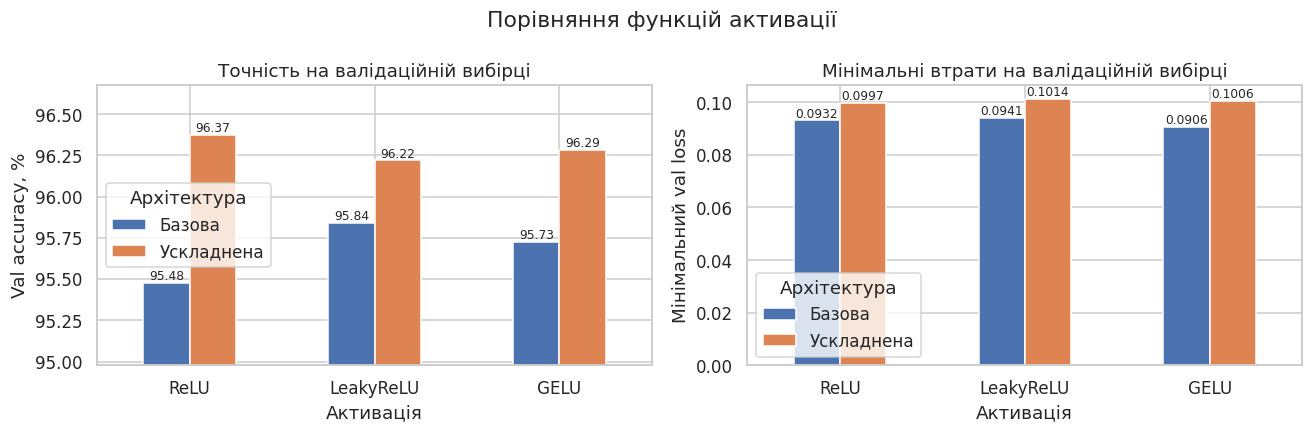

In [43]:
# Метрики якості з бібліотеки scikit-learn
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Список рядків підсумкової таблиці
rows = []
# Оцінюємо кожну навчену модель на валідаційній вибірці
for key, model in trained_models.items():
    # Розбиваємо назву експерименту на архітектуру та активацію
    arch, act = key.split(" + ")
    # Ймовірність класу satisfied для кожного запису validation
    proba = model.predict(X_val_sc, verbose=0).ravel()
    # Перетворюємо ймовірність у клас за порогом 0.5
    pred = (proba >= 0.5).astype(int)
    # Історія навчання цієї моделі
    h = histories[key]
    # Додаємо рядок із результатами
    rows.append({
        "Архітектура": arch,
        "Активація": act,
        "Val accuracy, %": accuracy_score(y_val, pred) * 100,      # частка правильних прогнозів
        "Val F1, %": f1_score(y_val, pred) * 100,                  # баланс precision і recall
        "Val ROC-AUC, %": roc_auc_score(y_val, proba) * 100,       # якість ранжування ймовірностей
        "Мін. val loss": min(h["val_loss"]),                       # найкращі втрати на validation
        "Епоха мін. val loss": int(np.argmin(h["val_loss"])) + 1,  # на якій епохі їх досягнуто
        f"Val loss (епоха {EPOCHS})": h["val_loss"][-1],           # втрати в кінці навчання
        "Час, с": train_times[key],                                # тривалість навчання
    })

# Формуємо таблицю результатів і виводимо її
act_results = pd.DataFrame(rows)
print(act_results.round(3).to_string(index=False))

# Зведена таблиця точності: рядки - активації, стовпці - архітектури
order = ["ReLU", "LeakyReLU", "GELU"]
pivot = act_results.pivot(index="Активація", columns="Архітектура",
                          values="Val accuracy, %").reindex(order)
print("\nVal accuracy, %:")
print(pivot.round(2).to_string())

# Два графіки поруч для порівняння активацій
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Лівий графік: точність на validation для кожної активації та архітектури
pivot.plot(kind="bar", ax=axes[0], rot=0, color=["#4C72B0", "#DD8452"])
# Звужуємо діапазон осі Y, щоб різницю між стовпцями було видно
axes[0].set_ylim(pivot.values.min() - 0.5, pivot.values.max() + 0.3)
axes[0].set_ylabel("Val accuracy, %")
axes[0].set_title("Точність на валідаційній вибірці")
# Підписуємо значення над стовпцями
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%.2f", fontsize=8)

# Правий графік: мінімальні втрати на validation (менше - краще)
loss_pivot = act_results.pivot(index="Активація", columns="Архітектура",
                               values="Мін. val loss").reindex(order)
loss_pivot.plot(kind="bar", ax=axes[1], rot=0, color=["#4C72B0", "#DD8452"])
axes[1].set_ylabel("Мінімальний val loss")
axes[1].set_title("Мінімальні втрати на валідаційній вибірці")
# Підписуємо значення над стовпцями
for c in axes[1].containers:
    axes[1].bar_label(c, fmt="%.4f", fontsize=8)

# Загальний заголовок, вирівнювання та відображення
fig.suptitle("Порівняння функцій активації")
fig.tight_layout()
plt.show()

In [45]:
# Кількість кроків (оновлень ваг) за одну епоху: розмір train / розмір батча, з округленням вгору
steps_per_epoch = int(np.ceil(len(X_train_bal) / BATCH_SIZE))

# Список рядків таблиці з параметрами навчання
rows = []
# Беремо параметри безпосередньо з навчених моделей, щоб підтвердити, що вони однакові
for key, model in trained_models.items():
    rows.append({
        "Модель": key,
        "Оптимізатор": model.optimizer.__class__.__name__,              # назва класу оптимізатора
        "Learning rate": float(model.optimizer.learning_rate.numpy()),  # фактична швидкість навчання
        "Епох": len(histories[key]["loss"]),                            # скільки епох пройдено
        "Batch size": BATCH_SIZE,                                       # розмір батча
        "Кроків за епоху": steps_per_epoch,                             # оновлень ваг за епоху
        "Функція втрат": model.loss,                                    # функція втрат моделі
        "Час, с": round(train_times[key], 1),                           # тривалість навчання
    })

# Формуємо таблицю і виводимо її
train_cfg = pd.DataFrame(rows)
print(train_cfg.to_string(index=False))
# Загальна кількість оновлень ваг за все навчання однієї моделі
print(f"\nОновлень ваг за все навчання однієї моделі: "
      f"{steps_per_epoch} x {EPOCHS} = {steps_per_epoch * EPOCHS}")
# Перевіряємо, що в кожному стовпці гіперпараметрів лише одне унікальне значення
same = train_cfg[["Оптимізатор", "Learning rate", "Епох", "Batch size"]].nunique().eq(1).all()
print("Гіперпараметри однакові для всіх 6 моделей:", "так" if same else "ні")

                Модель Оптимізатор  Learning rate  Епох  Batch size  Кроків за епоху       Функція втрат  Час, с
         Базова + ReLU        Adam          0.001    20         256              322 binary_crossentropy    22.7
    Базова + LeakyReLU        Adam          0.001    20         256              322 binary_crossentropy    23.0
         Базова + GELU        Adam          0.001    20         256              322 binary_crossentropy    31.1
     Ускладнена + ReLU        Adam          0.001    20         256              322 binary_crossentropy    42.0
Ускладнена + LeakyReLU        Adam          0.001    20         256              322 binary_crossentropy    39.1
     Ускладнена + GELU        Adam          0.001    20         256              322 binary_crossentropy    47.1

Оновлень ваг за все навчання однієї моделі: 322 x 20 = 6440
Гіперпараметри однакові для всіх 6 моделей: так


In [46]:
# Контрольні епохи для зведених таблиць
checkpoints = [1, 5, 10, 15, 20]

# Таблиця точності на validation: рядки - моделі, стовпці - контрольні епохи
acc_table = pd.DataFrame(
    {f"Епоха {e}": [h["val_accuracy"][e - 1] * 100 for h in histories.values()]
     for e in checkpoints},
    index=list(histories.keys()))

# Таблиця втрат на validation: рядки - моделі, стовпці - контрольні епохи
loss_table = pd.DataFrame(
    {f"Епоха {e}": [h["val_loss"][e - 1] for h in histories.values()]
     for e in checkpoints},
    index=list(histories.keys()))

# Виводимо обидві таблиці
print("Val accuracy, % на контрольних епохах:")
print(acc_table.round(2).to_string())
print("\nVal loss на контрольних епохах:")
print(loss_table.round(4).to_string())

Val accuracy, % на контрольних епохах:
                        Епоха 1  Епоха 5  Епоха 10  Епоха 15  Епоха 20
Базова + ReLU             94.54    95.73     95.86     95.68     95.48
Базова + LeakyReLU        94.26    95.53     95.96     95.69     95.84
Базова + GELU             94.30    95.95     96.02     95.88     95.73
Ускладнена + ReLU         93.03    95.69     96.00     96.09     96.37
Ускладнена + LeakyReLU    92.94    95.62     95.83     96.09     96.22
Ускладнена + GELU         93.84    95.74     96.08     96.17     96.29

Val loss на контрольних епохах:
                        Епоха 1  Епоха 5  Епоха 10  Епоха 15  Епоха 20
Базова + ReLU            0.1323   0.0961    0.0947    0.1031    0.1162
Базова + LeakyReLU       0.1374   0.1013    0.0941    0.0977    0.1012
Базова + GELU            0.1397   0.0973    0.0912    0.1005    0.1206
Ускладнена + ReLU        0.1917   0.1248    0.1101    0.1065    0.0997
Ускладнена + LeakyReLU   0.1964   0.1294    0.1132    0.1063    0.1014
Ускла

                        Загальний час, с  Час на епоху, с
Базова + ReLU                      22.67             1.13
Базова + LeakyReLU                 23.00             1.15
Базова + GELU                      31.13             1.56
Ускладнена + ReLU                  42.01             2.10
Ускладнена + LeakyReLU             39.11             1.96
Ускладнена + GELU                  47.14             2.36


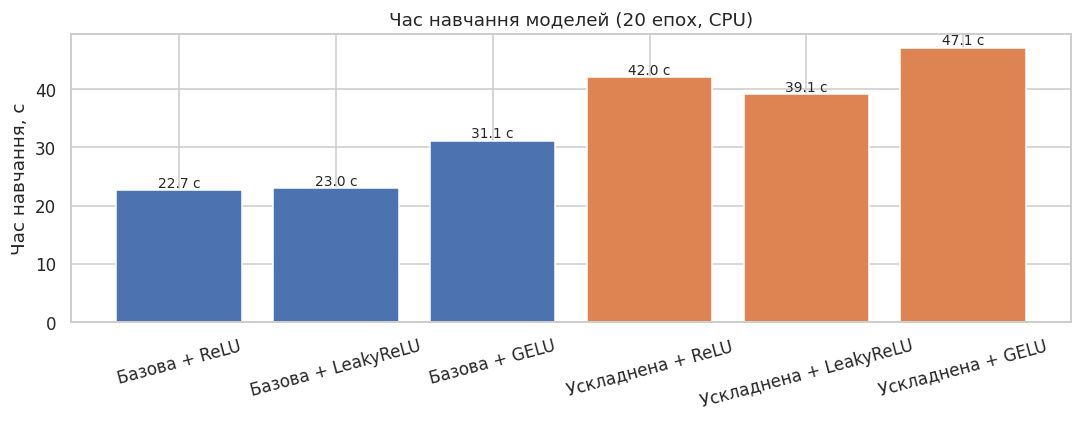

In [47]:
# Таблиця часу: загальний час навчання і середній час на одну епоху
time_df = pd.DataFrame({
    "Загальний час, с": pd.Series(train_times),
    "Час на епоху, с": pd.Series(train_times) / EPOCHS,
})
# Виводимо таблицю
print(time_df.round(2).to_string())

# Стовпчикова діаграма часу навчання кожної моделі
fig, ax = plt.subplots(figsize=(10, 4))
# Колір залежить від архітектури: синій - базова, помаранчевий - ускладнена
colors = ["#4C72B0" if k.startswith("Базова") else "#DD8452" for k in time_df.index]
# Малюємо стовпчики
bars = ax.bar(time_df.index, time_df["Загальний час, с"], color=colors)
# Підписуємо час над кожним стовпчиком
ax.bar_label(bars, fmt="%.1f с", fontsize=9)
# Підпис осі Y і заголовок графіка
ax.set_ylabel("Час навчання, с")
ax.set_title(f"Час навчання моделей ({EPOCHS} епох, CPU)")
# Нахиляємо підписи моделей, щоб вони не накладались
ax.tick_params(axis="x", rotation=15)
# Вирівнюємо відступи та відображаємо графік
fig.tight_layout()
plt.show()

In [48]:
# Метрики якості з бібліотеки scikit-learn
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

# Словники для збереження ймовірностей і прогнозів кожної моделі (знадобляться для графіків)
test_proba = {}
test_pred = {}
# Список рядків таблиці метрик
rows = []

# Оцінюємо кожну навчену модель на тестовій вибірці, яку вона ще не бачила
for key, model in trained_models.items():
    # Ймовірність класу satisfied для кожного запису test
    proba = model.predict(X_test_sc, verbose=0).ravel()
    # Перетворюємо ймовірність у клас за порогом 0.5
    pred = (proba >= 0.5).astype(int)
    # Зберігаємо ймовірності та прогнози моделі
    test_proba[key] = proba
    test_pred[key] = pred
    # Обчислюємо метрики і додаємо рядок у таблицю
    rows.append({
        "Модель": key,
        "Accuracy": accuracy_score(y_test, pred),                    # частка всіх правильних прогнозів
        "Balanced accuracy": balanced_accuracy_score(y_test, pred),  # середній recall обох класів, стійка до дисбалансу
        "Precision": precision_score(y_test, pred),                  # частка справді задоволених серед спрогнозованих задоволеними
        "Recall": recall_score(y_test, pred),                        # частка знайдених задоволених серед усіх задоволених
        "F1": f1_score(y_test, pred),                                # гармонійне середнє precision і recall
        "ROC-AUC": roc_auc_score(y_test, proba),                     # якість розділення класів за ймовірностями
    })

# Формуємо таблицю, переводимо значення у відсотки і виводимо її
test_results = pd.DataFrame(rows).set_index("Модель") * 100
print(f"Метрики на тестовій вибірці ({len(y_test)} записів), %:")
print(test_results.round(2).to_string())

# Визначаємо найкращу модель за F1 та за ROC-AUC
best_f1 = test_results["F1"].idxmax()
best_auc = test_results["ROC-AUC"].idxmax()
print(f"\nНайкраща модель за F1: {best_f1} ({test_results.loc[best_f1, 'F1']:.2f}%)")
print(f"Найкраща модель за ROC-AUC: {best_auc} ({test_results.loc[best_auc, 'ROC-AUC']:.2f}%)")

Метрики на тестовій вибірці (15586 записів), %:
                        Accuracy  Balanced accuracy  Precision  Recall     F1  ROC-AUC
Модель                                                                                
Базова + ReLU              95.15              95.19      93.45   95.50  94.46    99.32
Базова + LeakyReLU         95.54              95.40      95.33   94.33  94.83    99.33
Базова + GELU              95.53              95.39      95.33   94.31  94.82    99.29
Ускладнена + ReLU          96.09              95.94      96.08   94.83  95.45    99.48
Ускладнена + LeakyReLU     96.08              95.93      96.13   94.77  95.44    99.46
Ускладнена + GELU          96.14              96.00      96.08   94.97  95.52    99.48

Найкраща модель за F1: Ускладнена + GELU (95.52%)
Найкраща модель за ROC-AUC: Ускладнена + ReLU (99.48%)


In [49]:
# Функція формує звіт з precision, recall і F1 окремо для кожного класу
from sklearn.metrics import classification_report

# Виводимо назву найкращої моделі за F1
print(f"Детальний звіт класифікації для моделі: {best_f1}\n")
# Звіт по обох класах + середні значення (macro і weighted), 4 знаки після коми
print(classification_report(y_test, test_pred[best_f1],
                            target_names=["neutral or dissatisfied", "satisfied"],
                            digits=4))

Детальний звіт класифікації для моделі: Ускладнена + GELU

                         precision    recall  f1-score   support

neutral or dissatisfied     0.9618    0.9703    0.9661      8832
              satisfied     0.9608    0.9497    0.9552      6754

               accuracy                         0.9614     15586
              macro avg     0.9613    0.9600    0.9606     15586
           weighted avg     0.9614    0.9614    0.9613     15586



                          TN   FP   FN    TP  Помилок усього
Модель                                                      
Базова + ReLU           8380  452  304  6450             756
Базова + LeakyReLU      8520  312  383  6371             695
Базова + GELU           8520  312  384  6370             696
Ускладнена + ReLU       8571  261  349  6405             610
Ускладнена + LeakyReLU  8574  258  353  6401             611
Ускладнена + GELU       8570  262  340  6414             602


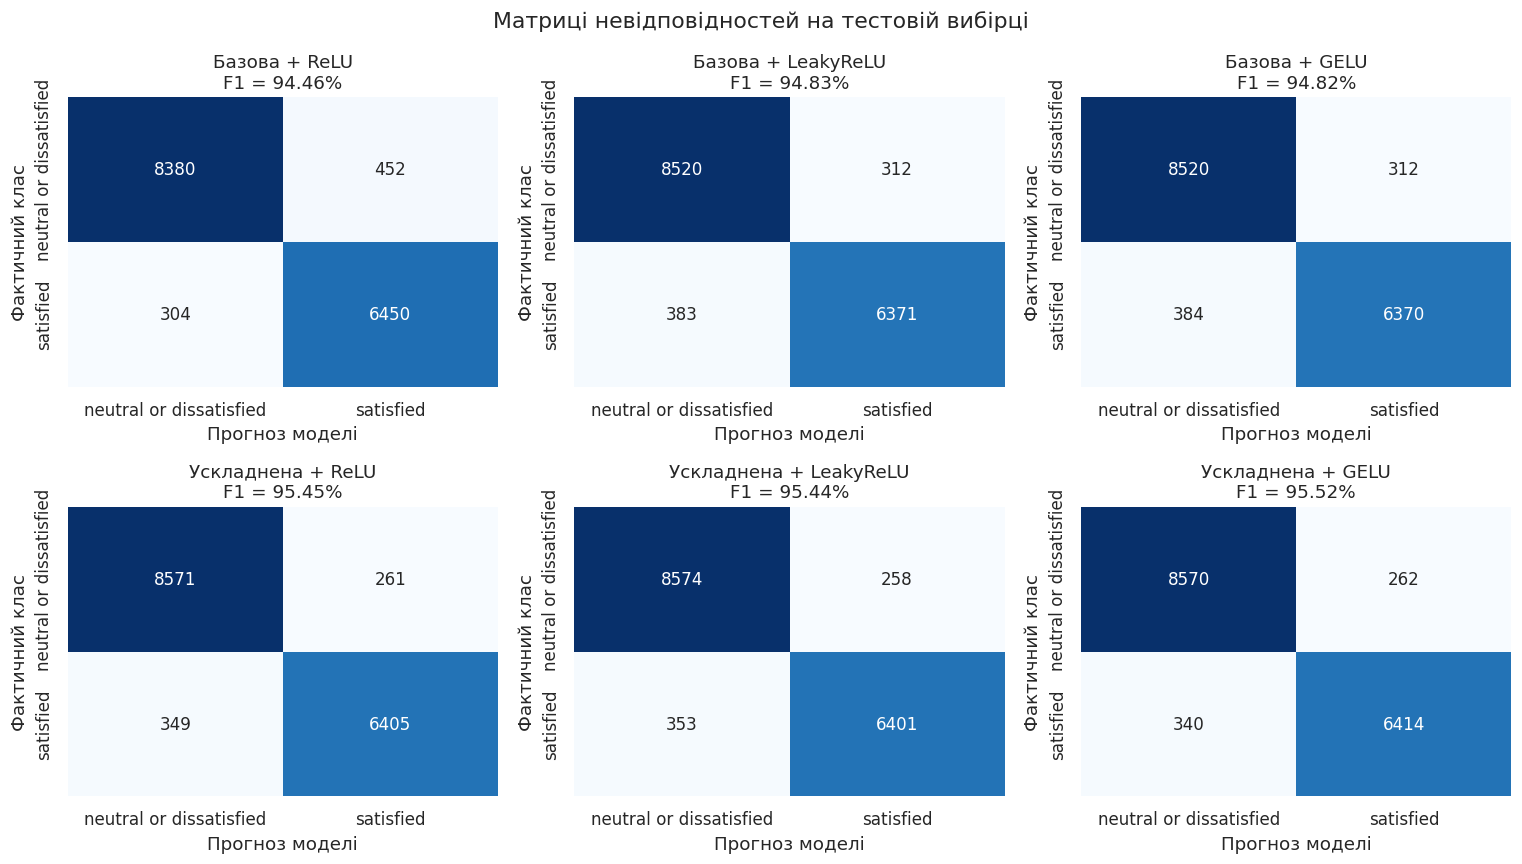

In [51]:
# Функція будує матрицю невідповідностей (confusion matrix)
from sklearn.metrics import confusion_matrix
# Таблиця з кількістю правильних і хибних прогнозів кожної моделі
cm_rows = []
for key in test_pred:
    # TN - правильно визначені незадоволені, FP - незадоволені, помилково названі задоволеними,
    # FN - задоволені, помилково названі незадоволеними, TP - правильно визначені задоволені
    tn, fp, fn, tp = confusion_matrix(y_test, test_pred[key]).ravel()
    cm_rows.append({"Модель": key, "TN": tn, "FP": fp, "FN": fn, "TP": tp,
                    "Помилок усього": fp + fn})
# Виводимо таблицю
print(pd.DataFrame(cm_rows).set_index("Модель").to_string())
# Сітка 2 x 3: по одній матриці для кожної моделі
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, key in zip(axes.ravel(), test_pred.keys()):
    # Матриця невідповідностей поточної моделі
    cm = confusion_matrix(y_test, test_pred[key])
    # Теплова карта з кількістю записів у кожній клітинці
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["neutral or dissatisfied", "satisfied"],
                yticklabels=["neutral or dissatisfied", "satisfied"],
                annot_kws={"size": 11})
    # Заголовок з назвою моделі та її F1
    ax.set_title(f"{key}\nF1 = {test_results.loc[key, 'F1']:.2f}%")
    # Підписи осей
    ax.set_xlabel("Прогноз моделі")
    ax.set_ylabel("Фактичний клас")
# Загальний заголовок, вирівнювання та відображення
fig.suptitle("Матриці невідповідностей на тестовій вибірці")
fig.tight_layout()
plt.show()

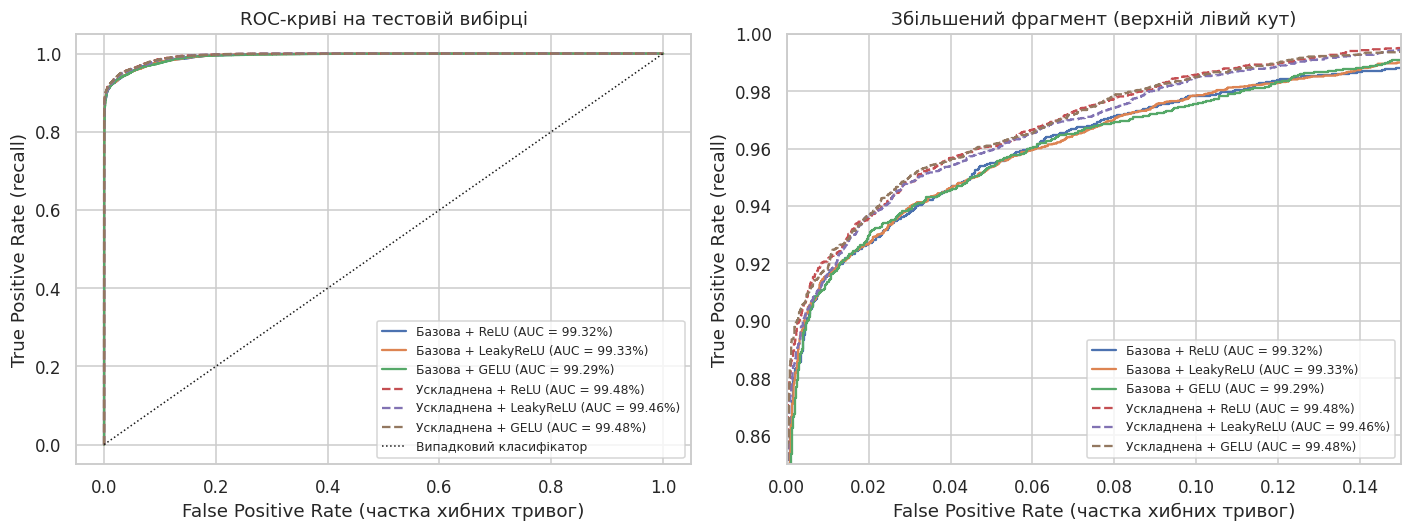

In [52]:
# Функція обчислює точки ROC-кривої
from sklearn.metrics import roc_curve

# Два графіки: повна ROC-крива і збільшений верхній лівий кут
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for key, proba in test_proba.items():
    # FPR - частка хибних тривог, TPR - частка знайдених задоволених при різних порогах
    fpr, tpr, _ = roc_curve(y_test, proba)
    # Базові моделі - суцільна лінія, ускладнені - пунктир
    style = "-" if key.startswith("Базова") else "--"
    # Малюємо криву на обох графіках
    for ax in axes:
        ax.plot(fpr, tpr, linestyle=style, linewidth=1.5,
                label=f"{key} (AUC = {test_results.loc[key, 'ROC-AUC']:.2f}%)")

# Діагональ - ROC-крива випадкового класифікатора (AUC = 50%)
axes[0].plot([0, 1], [0, 1], "k:", linewidth=1, label="Випадковий класифікатор")
axes[0].set_title("ROC-криві на тестовій вибірці")
# На другому графіку збільшуємо зону, де криві відрізняються
axes[1].set_xlim(0, 0.15)
axes[1].set_ylim(0.85, 1.0)
axes[1].set_title("Збільшений фрагмент (верхній лівий кут)")
# Підписи осей і легенда для обох графіків
for ax in axes:
    ax.set_xlabel("False Positive Rate (частка хибних тривог)")
    ax.set_ylabel("True Positive Rate (recall)")
    ax.legend(fontsize=8, loc="lower right")
# Вирівнюємо відступи та відображаємо графіки
fig.tight_layout()
plt.show()

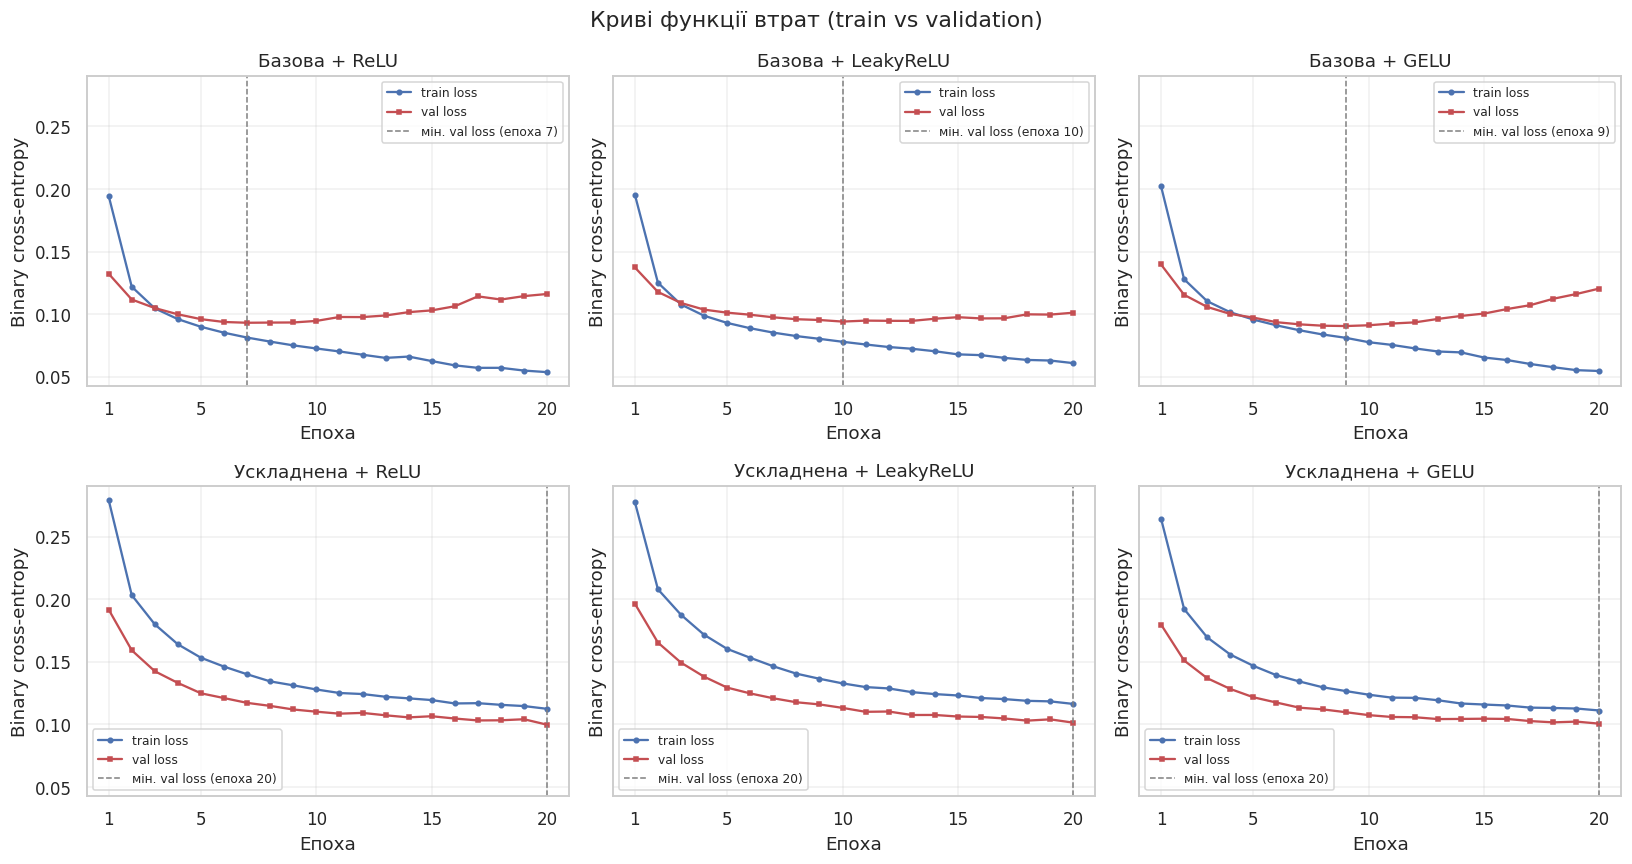

In [53]:
# Номери епох для осі X: від 1 до 20
epochs_range = range(1, EPOCHS + 1)
# Позначки на осі X: 1, 5, 10, 15, 20
ticks = [1] + list(range(5, EPOCHS + 1, 5))

# Сітка 2 x 3: верхній ряд - базові мережі, нижній - ускладнені; спільна вісь Y для порівняння
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for ax, (key, h) in zip(axes.ravel(), histories.items()):
    # Втрати на навчальній вибірці по епохах
    ax.plot(epochs_range, h["loss"], "o-", markersize=3, color="#4C72B0", label="train loss")
    # Втрати на валідаційній вибірці по епохах
    ax.plot(epochs_range, h["val_loss"], "s-", markersize=3, color="#C44E52", label="val loss")
    # Епоха, на якій валідаційні втрати мінімальні (найкращий стан моделі)
    best_ep = int(np.argmin(h["val_loss"])) + 1
    # Позначаємо цю епоху вертикальною пунктирною лінією
    ax.axvline(best_ep, color="gray", linestyle="--", linewidth=1,
               label=f"мін. val loss (епоха {best_ep})")
    # Заголовок, підписи осей і позначки епох
    ax.set_title(key)
    ax.set_xlabel("Епоха")
    ax.set_ylabel("Binary cross-entropy")
    ax.set_xticks(ticks)
    # Легенда і сітка
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Загальний заголовок, вирівнювання та відображення
fig.suptitle("Криві функції втрат (train vs validation)")
fig.tight_layout()
plt.show()

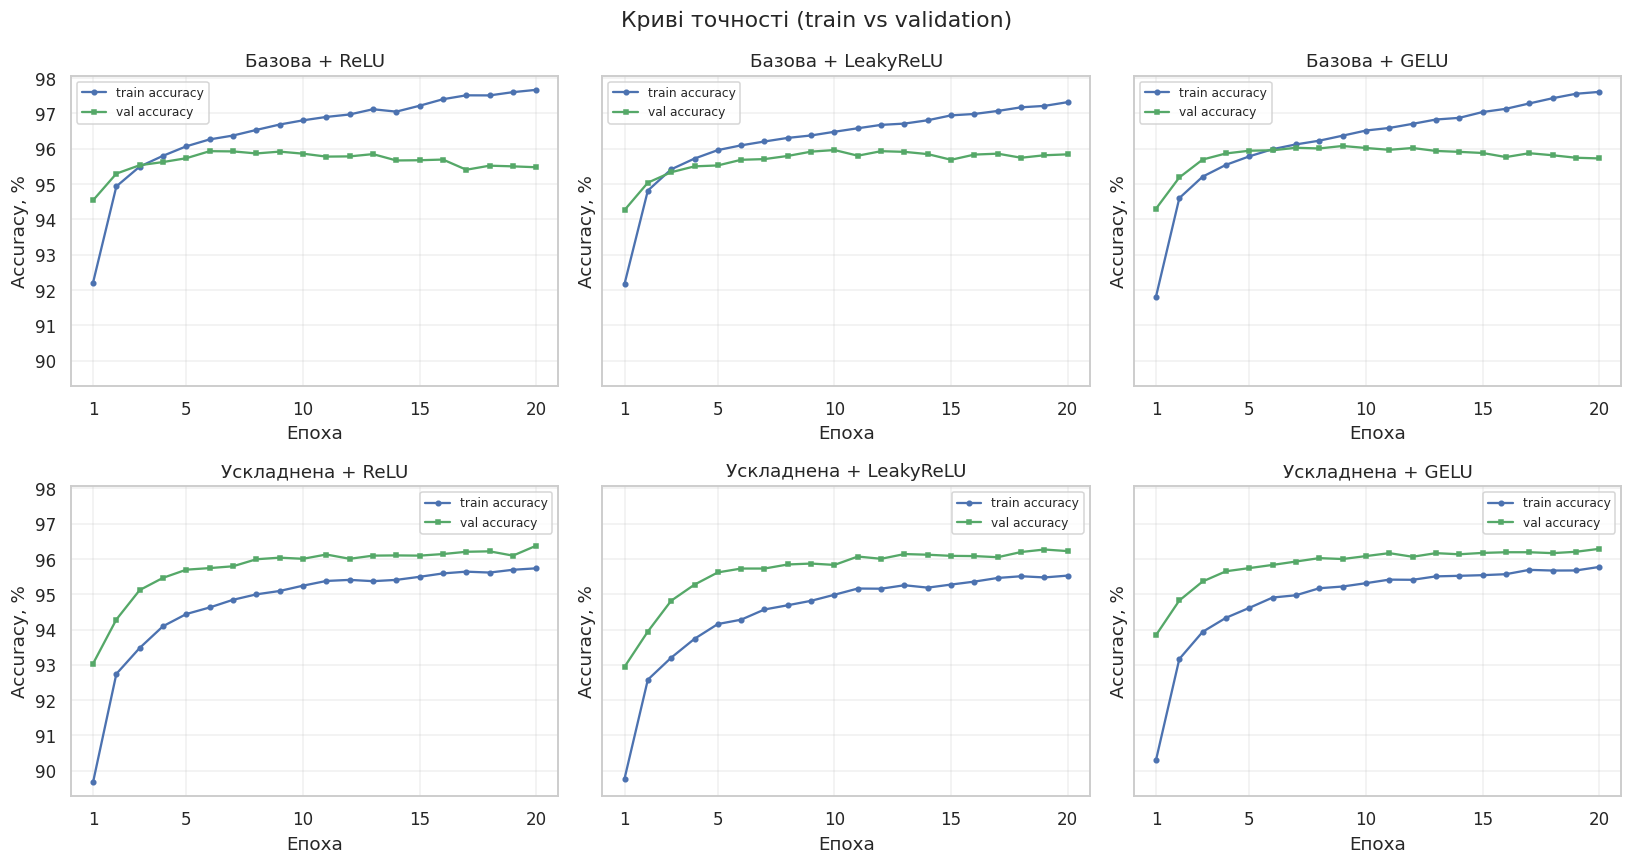

In [54]:
# Сітка 2 x 3 зі спільною віссю Y
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for ax, (key, h) in zip(axes.ravel(), histories.items()):
    # Точність на навчальній вибірці, у відсотках
    ax.plot(epochs_range, np.array(h["accuracy"]) * 100, "o-", markersize=3,
            color="#4C72B0", label="train accuracy")
    # Точність на валідаційній вибірці, у відсотках
    ax.plot(epochs_range, np.array(h["val_accuracy"]) * 100, "s-", markersize=3,
            color="#55A868", label="val accuracy")
    # Заголовок, підписи осей і позначки епох
    ax.set_title(key)
    ax.set_xlabel("Епоха")
    ax.set_ylabel("Accuracy, %")
    ax.set_xticks(ticks)
    # Легенда і сітка
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Загальний заголовок, вирівнювання та відображення
fig.suptitle("Криві точності (train vs validation)")
fig.tight_layout()
plt.show()

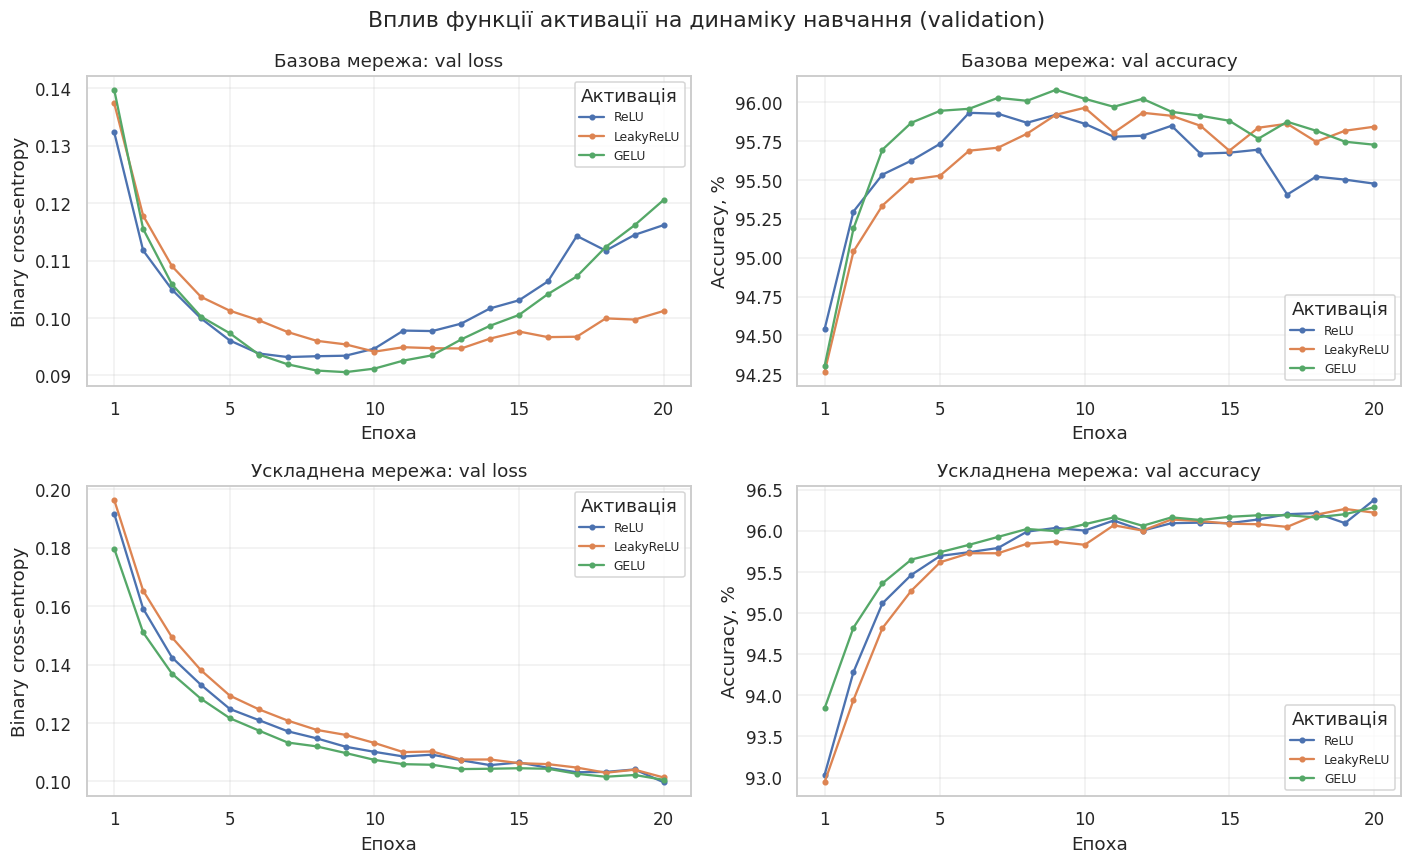

In [55]:
# Кольори для кожної функції активації
act_colors = {"ReLU": "#4C72B0", "LeakyReLU": "#DD8452", "GELU": "#55A868"}

# Сітка 2 x 2: рядки - архітектури, стовпці - val loss і val accuracy
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for row, arch in enumerate(["Базова", "Ускладнена"]):
    for act, color in act_colors.items():
        # Історія навчання моделі з цією архітектурою та активацією
        h = histories[f"{arch} + {act}"]
        # Лівий графік: валідаційні втрати
        axes[row, 0].plot(epochs_range, h["val_loss"], "o-", markersize=3,
                          color=color, label=act)
        # Правий графік: валідаційна точність у відсотках
        axes[row, 1].plot(epochs_range, np.array(h["val_accuracy"]) * 100, "o-",
                          markersize=3, color=color, label=act)
    # Заголовки та підписи осі Y для рядка
    axes[row, 0].set_title(f"{arch} мережа: val loss")
    axes[row, 0].set_ylabel("Binary cross-entropy")
    axes[row, 1].set_title(f"{arch} мережа: val accuracy")
    axes[row, 1].set_ylabel("Accuracy, %")
    # Спільне оформлення обох графіків рядка
    for ax in axes[row]:
        ax.set_xlabel("Епоха")
        ax.set_xticks(ticks)
        ax.legend(title="Активація", fontsize=8)
        ax.grid(alpha=0.3)

# Загальний заголовок, вирівнювання та відображення
fig.suptitle("Вплив функції активації на динаміку навчання (validation)")
fig.tight_layout()
plt.show()

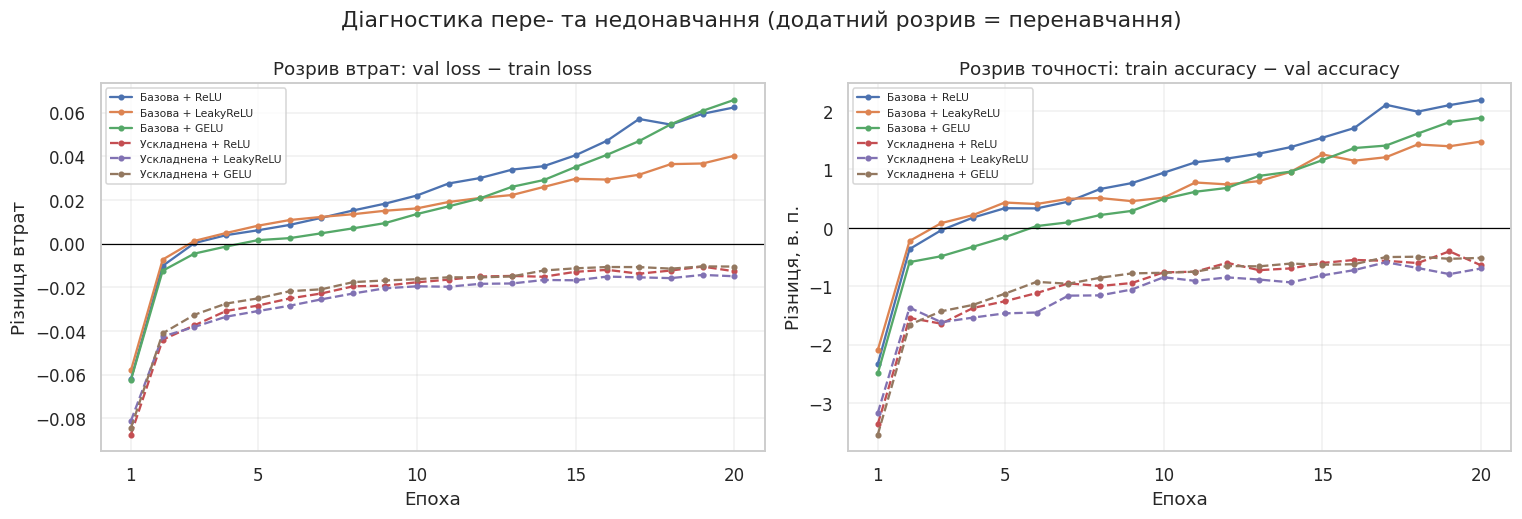

                        Епоха мін. val loss  Мін. val loss  Val loss (кінець)  Зростання val loss, %  Розрив loss (кінець)  Розрив acc, в. п. (кінець)
Модель                                                                                                                                                
Базова + ReLU                             7         0.0932             0.1162                24.6497                0.0624                      2.1928
Базова + LeakyReLU                       10         0.0941             0.1012                 7.5186                0.0402                      1.4789
Базова + GELU                             9         0.0906             0.1206                33.0896                0.0659                      1.8844
Ускладнена + ReLU                        20         0.0997             0.0997                 0.0000               -0.0127                     -0.6416
Ускладнена + LeakyReLU                   20         0.1014             0.1014                 

In [56]:
# Два графіки: розрив втрат і розрив точності між train та validation
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for key, h in histories.items():
    # Базові моделі - суцільна лінія, ускладнені - пунктир
    style = "-" if key.startswith("Базова") else "--"
    # Розрив втрат: наскільки val loss більший за train loss
    loss_gap = np.array(h["val_loss"]) - np.array(h["loss"])
    # Розрив точності: наскільки train accuracy більша за val accuracy, у в. п.
    acc_gap = (np.array(h["accuracy"]) - np.array(h["val_accuracy"])) * 100
    # Малюємо обидва розриви
    axes[0].plot(epochs_range, loss_gap, linestyle=style, marker="o", markersize=3, label=key)
    axes[1].plot(epochs_range, acc_gap, linestyle=style, marker="o", markersize=3, label=key)

# Заголовки та підписи осі Y
axes[0].set_title("Розрив втрат: val loss − train loss")
axes[0].set_ylabel("Різниця втрат")
axes[1].set_title("Розрив точності: train accuracy − val accuracy")
axes[1].set_ylabel("Різниця, в. п.")
# Спільне оформлення: нульова лінія, осі, легенда, сітка
for ax in axes:
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Епоха")
    ax.set_xticks(ticks)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
# Загальний заголовок, вирівнювання та відображення
fig.suptitle("Діагностика пере- та недонавчання (додатний розрив = перенавчання)")
fig.tight_layout()
plt.show()

# Таблиця з кількісними ознаками перенавчання для кожної моделі
gap_rows = []
for key, h in histories.items():
    gap_rows.append({
        "Модель": key,
        "Епоха мін. val loss": int(np.argmin(h["val_loss"])) + 1,             # найкраща епоха
        "Мін. val loss": min(h["val_loss"]),                                  # найкращі втрати
        "Val loss (кінець)": h["val_loss"][-1],                               # втрати на 20-й епосі
        "Зростання val loss, %": (h["val_loss"][-1] / min(h["val_loss"]) - 1) * 100,  # наскільки погіршились
        "Розрив loss (кінець)": h["val_loss"][-1] - h["loss"][-1],            # розрив втрат на 20-й епосі
        "Розрив acc, в. п. (кінець)": (h["accuracy"][-1] - h["val_accuracy"][-1]) * 100,  # розрив точності
    })
# Виводимо таблицю
print(pd.DataFrame(gap_rows).set_index("Модель").round(4).to_string())

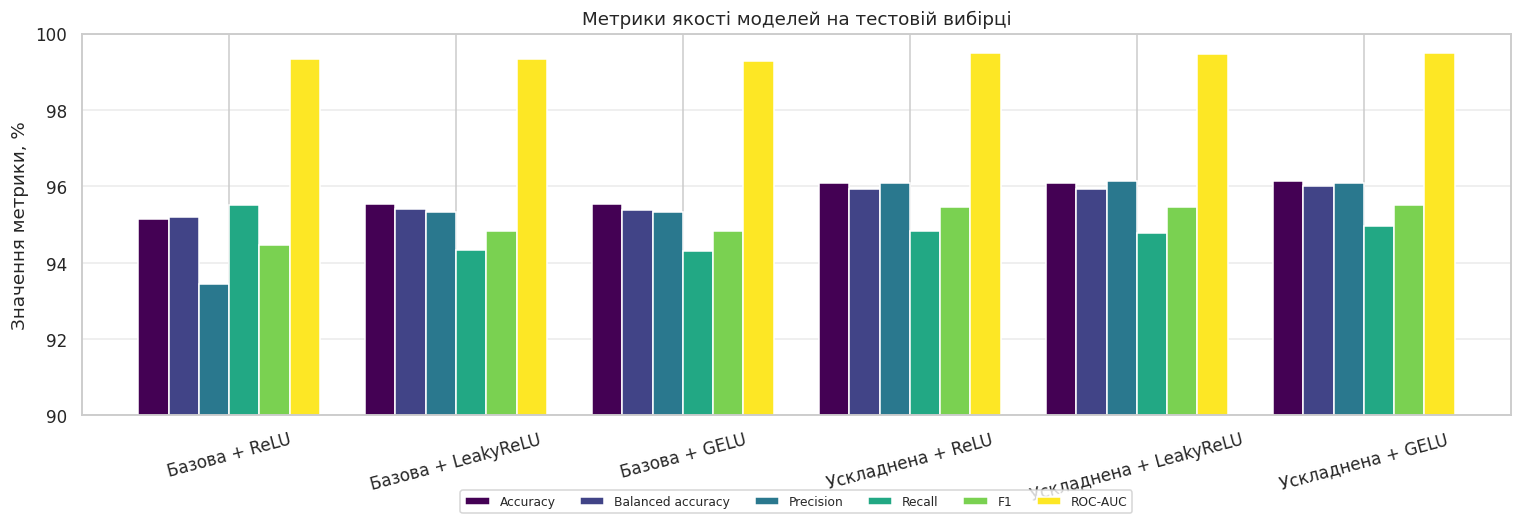

In [57]:
# Метрики, які відображаємо на графіку (обчислені в пункті 9)
metric_cols = ["Accuracy", "Balanced accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

# Згрупована стовпчикова діаграма: для кожної моделі - 6 стовпців метрик
ax = test_results[metric_cols].plot(kind="bar", figsize=(14, 5), width=0.8,
                                    colormap="viridis", edgecolor="white")
# Звужуємо діапазон осі Y, щоб різницю між моделями було видно
ax.set_ylim(90, 100)
# Підписи осей і заголовок
ax.set_ylabel("Значення метрики, %")
ax.set_xlabel("")
ax.set_title("Метрики якості моделей на тестовій вибірці")
# Нахиляємо назви моделей, щоб вони не накладались
ax.tick_params(axis="x", rotation=15)
# Легенду розміщуємо під графіком в один рядок
ax.legend(ncol=6, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.18))
# Горизонтальна сітка
ax.grid(axis="y", alpha=0.4)
# Вирівнюємо відступи та відображаємо графік
plt.tight_layout()
plt.show()